# Modelado de Churn - Predicción y Segmentación

Notebook de modelado para predicción de churn con múltiples algoritmos de clasificación.  
**Objetivo**: Entrenar, evaluar y comparar modelos; generar probabilidades de churn y segmentos de riesgo.

## 1. LIBRERÍAS E IMPORTS

Carga todas las librerías necesarias para preprocesamiento, modelado, evaluación y visualización.

In [1]:
# ============================================================
# IMPORTS - Librerías principales
# ============================================================
import pandas as pd          # Manipulación de datos tabulares
import numpy as np           # Cálculos numéricos y arrays
import matplotlib.pyplot as plt  # Visualización base
import seaborn as sns        # Visualización estadística avanzada
import warnings

warnings.filterwarnings('ignore')

# Configuración visual: estilo y parámetros de gráficos
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'figure.figsize': (10, 6),
    'figure.dpi': 150,
    'font.size': 11,
    'axes.titlesize': 14,
    'axes.titleweight': 'bold',
    'font.family': 'sans-serif',
})

# Paleta de colores consistente con EDA
PALETTE = ['#0F172A', '#1D4ED8', '#0EA5A4', '#22C55E', '#F59E0B', '#EF4444', '#A855F7', '#E5E7EB']
TEAL = '#0EA5A4'
TERRA = '#EF4444'
DARK_TEAL = '#0F172A'
TEXT_COLOR = '#111827'
sns.set_palette(PALETTE)

print('✓ Librerías cargadas correctamente.')
print(f'  Pandas version: {pd.__version__}')
print(f'  NumPy version: {np.__version__}')

✓ Librerías cargadas correctamente.
  Pandas version: 3.0.1
  NumPy version: 2.4.4


In [2]:
# ============================================================
# CARGA INICIAL DE DATOS
# Ruta relativa desde notebooks/modeling/ al dataset procesado
# ============================================================
data_path = '../../data/processed/user_features_churn.csv'
df = pd.read_csv(data_path)
print(f'✓ Dataset cargado: {data_path}')
print(f'  Dimensiones: {df.shape[0]:,} usuarios × {df.shape[1]} features')

✓ Dataset cargado: ../../data/processed/user_features_churn.csv
  Dimensiones: 70,386 usuarios × 31 features


In [3]:
# ============================================================
# INSPECCIÓN DE ESTRUCTURA
# Verifica tipos de datos, memoria usada y valores no-nulos
# ============================================================
print('\n📊 INFORMACIÓN DEL DATASET')
print('='*70)
df.info()
print('='*70)


📊 INFORMACIÓN DEL DATASET
<class 'pandas.DataFrame'>
RangeIndex: 70386 entries, 0 to 70385
Data columns (total 31 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   user_id                 70386 non-null  int64  
 1   total_orders            70386 non-null  int64  
 2   total_items             70386 non-null  int64  
 3   total_revenue           70386 non-null  float64
 4   first_purchase          70386 non-null  str    
 5   last_purchase           70386 non-null  str    
 6   unique_products         70386 non-null  int64  
 7   avg_order_value         70386 non-null  float64
 8   recency_days            70386 non-null  float64
 9   customer_tenure_days    70386 non-null  float64
 10  purchase_span_days      70386 non-null  float64
 11  avg_days_between        23716 non-null  float64
 12  return_count            70386 non-null  int64  
 13  unique_categories       70386 non-null  int64  
 14  unique_departments    

In [4]:
# Verificar valores nulos por columna (target de imputación)
print('\n🔍 NULOS POR COLUMNA')
print('='*70)
nulos = df.isnull().sum()
if nulos.sum() > 0:
    print(nulos[nulos > 0])
else:
    print('✅ No hay valores nulos en el dataset')
print('='*70)


🔍 NULOS POR COLUMNA
avg_days_between    46670
dtype: int64


In [5]:
# Muestra las primeras 5 filas para ver estructura de datos
print('\n📋 PRIMERAS FILAS DEL DATASET')
print('='*70)
df.head(5)


📋 PRIMERAS FILAS DEL DATASET


,user_id,total_orders,total_items,total_revenue,first_purchase,last_purchase,unique_products,avg_order_value,recency_days,customer_tenure_days,...,main_traffic_source,age,gender,country,signup_source,cart_to_purchase_ratio,total_events,browse_to_buy_ratio,is_churned,age_group
0,1,1,3,159.990000,2022-07-19 11:29:28+00:00,2022-07-20 11:05:38+00:00,3,159.990000,550.0,551.0,...,Email,62,F,South Korea,Search,3.0,30,3.0,1,60+
1,2,1,1,22.000000,2022-02-20 10:28:57+00:00,2022-02-20 10:28:57+00:00,1,22.000000,700.0,700.0,...,Email,65,M,Brasil,Organic,1.0,5,1.0,1,60+
2,3,4,5,402.200001,2023-03-10 07:14:45+00:00,2023-08-08 06:13:20+00:00,5,100.550000,166.0,317.0,...,Email,16,M,United States,Organic,1.4,29,1.4,1,<20
3,4,1,1,148.000000,2022-10-18 06:17:54+00:00,2022-10-18 06:17:54+00:00,1,148.000000,460.0,460.0,...,Email,12,F,United States,Search,1.0,5,1.0,1,<20
4,6,1,2,144.820004,2022-04-10 02:38:35+00:00,2022-04-11 01:07:13+00:00,2,144.820004,650.0,651.0,...,Facebook,65,M,Australia,Facebook,2.0,14,2.0,1,60+


In [6]:
# Estadísticas descriptivas de variables numéricas
print('\n📈 ESTADÍSTICAS DESCRIPTIVAS')
print('='*70)
df.describe()


📈 ESTADÍSTICAS DESCRIPTIVAS


,user_id,total_orders,total_items,total_revenue,unique_products,avg_order_value,recency_days,customer_tenure_days,purchase_span_days,avg_days_between,...,events_cart,events_department,events_home,events_product,events_purchase,age,cart_to_purchase_ratio,total_events,browse_to_buy_ratio,is_churned
count,70386.000000,70386.000000,70386.000000,70386.000000,70386.000000,70386.000000,70386.000000,70386.000000,70386.000000,23716.000000,...,70386.000000,70386.000000,70386.000000,70386.000000,70386.000000,70386.000000,70386.000000,70386.000000,70386.000000,70386.000000
mean,50041.055110,1.477481,2.143750,127.813035,2.143622,86.430557,401.900477,525.430526,123.288012,278.640250,...,4.468488,4.468460,1.133237,4.468474,2.349516,41.047652,1.529204,16.888174,1.529202,0.711463
std,28865.113894,0.776994,1.494151,132.663885,1.493958,84.760026,379.916458,427.107446,260.868280,273.241642,...,5.241387,5.241487,0.850629,5.241406,1.646187,17.025807,0.786592,17.185374,0.786605,0.453086
min,1.000000,1.000000,1.000000,0.020000,1.000000,0.020000,0.000000,2.000000,0.000000,0.000000,...,1.000000,1.000000,0.000000,1.000000,1.000000,12.000000,1.000000,5.000000,1.000000,0.000000
25%,25040.250000,1.000000,1.000000,39.950001,1.000000,34.150002,98.000000,164.000000,0.000000,75.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,26.000000,1.000000,5.000000,1.000000,0.000000
50%,50130.500000,1.000000,2.000000,84.894997,2.000000,61.214167,280.000000,421.000000,0.000000,194.000000,...,2.000000,2.000000,1.000000,2.000000,2.000000,41.000000,1.000000,10.000000,1.000000,1.000000
75%,74966.750000,2.000000,3.000000,170.907500,3.000000,109.989998,601.000000,805.000000,99.000000,396.000000,...,5.000000,5.000000,1.000000,5.000000,3.000000,56.000000,2.000000,19.000000,2.000000,1.000000
max,100000.000000,4.000000,14.000000,1738.969982,14.000000,1341.489998,1840.000000,1841.000000,1748.000000,1744.000000,...,50.000000,50.000000,4.000000,50.000000,14.000000,70.000000,5.000000,164.000000,5.000000,1.000000


In [7]:
# ============================================================
# VALIDACIÓN: ALINEACIÓN CON EDA
# Verifica que el dataset sea el correcto y variables clave estén presentes
# ============================================================
print('\n🔍 VALIDACIÓN CONTRA EDA REPORT')
print('='*70)

# Verificar dimensiones esperadas
expected_users = 70386
actual_users = len(df)
print(f'\n1. TAMAÑO DEL DATASET:')
print(f'   EDA reportó: {expected_users:,} usuarios')
print(f'   Dataset actual: {actual_users:,} usuarios')
print(f'   ✅ MATCH' if actual_users == expected_users else f'   ⚠️  MISMATCH - Revisar')

# Verificar distribución del target
churned_count = df['is_churned'].sum()
active_count = len(df) - churned_count
churned_pct = churned_count / len(df) * 100
active_pct = active_count / len(df) * 100

print(f'\n2. DISTRIBUCIÓN DEL TARGET (is_churned):')
print(f'   EDA reportó: 71.1% churned (50,077) vs 28.9% activos (20,309)')
print(f'   Dataset actual: {churned_pct:.1f}% churned ({churned_count:,}) vs {active_pct:.1f}% activos ({active_count:,})')
print(f'   ✅ MATCH (±0.2%)' if abs(churned_pct - 71.1) < 0.2 else f'   ⚠️  MISMATCH - Revisar')

# Verificar variables clave del EDA
print(f'\n3. VARIABLES CLAVE RFM (EDA):')
rfm_features = ['total_orders', 'total_revenue', 'customer_tenure_days', 'avg_order_value']
for feat in rfm_features:
    present = feat in df.columns
    marker = '✓' if present else '✗'
    print(f'   {marker} {feat}')

print(f'\n4. VARIABLES CLAVE EVENTOS WEB (EDA):')
event_features = ['total_events', 'events_product', 'events_cart', 'events_purchase']
for feat in event_features:
    present = feat in df.columns
    marker = '✓' if present else '✗'
    print(f'   {marker} {feat}')

print(f'\n5. VARIABLES DEMOGRÁFICAS (EDA):')
demo_features = ['age', 'gender', 'country']
for feat in demo_features:
    present = feat in df.columns
    marker = '✓' if present else '✗'
    print(f'   {marker} {feat}')

print(f'\n   Total de variables en dataset: {len(df.columns)}')
print(f'   EDA reportó: 31 variables')

print('\n✅ VALIDACIÓN COMPLETADA')
print('='*70)


🔍 VALIDACIÓN CONTRA EDA REPORT

1. TAMAÑO DEL DATASET:
   EDA reportó: 70,386 usuarios
   Dataset actual: 70,386 usuarios
   ✅ MATCH

2. DISTRIBUCIÓN DEL TARGET (is_churned):
   EDA reportó: 71.1% churned (50,077) vs 28.9% activos (20,309)
   Dataset actual: 71.1% churned (50,077) vs 28.9% activos (20,309)
   ✅ MATCH (±0.2%)

3. VARIABLES CLAVE RFM (EDA):
   ✓ total_orders
   ✓ total_revenue
   ✓ customer_tenure_days
   ✓ avg_order_value

4. VARIABLES CLAVE EVENTOS WEB (EDA):
   ✓ total_events
   ✓ events_product
   ✓ events_cart
   ✓ events_purchase

5. VARIABLES DEMOGRÁFICAS (EDA):
   ✓ age
   ✓ gender
   ✓ country

   Total de variables en dataset: 31
   EDA reportó: 31 variables

✅ VALIDACIÓN COMPLETADA


## 2. PREPARACIÓN Y LIMPIEZA DE DATOS

Esta sección realiza transformaciones clave:
- Conversión de columnas temporales a formato datetime
- Tratamiento de valores nulos
- Derivación de variables auxiliares

In [8]:
# ============================================================
# CONVERSIÓN DE TIPOS DE DATOS
# Convierte columnas de fechas a datetime para operaciones temporales
# ============================================================
data_path = '../../data/processed/user_features_churn.csv'
df = pd.read_csv(data_path)

# Conversión de columnas temporales (si existen en el dataset)
datetime_cols = ['first_purchase', 'last_purchase']
for col in datetime_cols:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], errors='coerce')
        print(f'✓ {col} convertida a datetime')

print(f'\n✅ Tipos de datos actualizados. Dataset: {df.shape}')

✓ first_purchase convertida a datetime
✓ last_purchase convertida a datetime

✅ Tipos de datos actualizados. Dataset: (70386, 31)


## 3. TRATAMIENTO DE VALORES NULOS

Imputación estratégica de valores faltantes:
- `avg_days_between` → relleno con 0 (clientes de una sola compra)
- `has_multiple_orders` → derivada binaria basada en `total_orders`

In [9]:
# ============================================================
# IMPUTACIÓN Y DERIVACIÓN DE VARIABLES
# Maneja nulos y crea nuevas features para enriquecer el modelo
# ============================================================
print('Imputación de variables...')

# Rellena promedio de días entre compras (0 para clientes con 1 compra)
if 'avg_days_between' in df.columns:
    df['avg_days_between'] = df['avg_days_between'].fillna(0)
    print(f'✓ avg_days_between: {df["avg_days_between"].isnull().sum()} nulos restantes')

# Crea variable binaria: 1 si el cliente hizo > 1 orden, 0 si no
if 'total_orders' in df.columns:
    df['has_multiple_orders'] = (df['total_orders'] > 1).astype(int)
    print(f'✓ has_multiple_orders: creada (1={df["has_multiple_orders"].sum()} clientes multi-orden)')

print(f'\n✅ Imputación completa. Nulos totales: {df.isnull().sum().sum()}')

Imputación de variables...
✓ avg_days_between: 0 nulos restantes
✓ has_multiple_orders: creada (1=23716 clientes multi-orden)

✅ Imputación completa. Nulos totales: 0


## 4. ELIMINACIÓN DE DATA LEAKAGE

**Concepto:** Evitar que información futura o derivada del target se use como predictor.

Variables eliminadas:
- `user_id`: identificador sin poder predictivo
- `first_purchase`, `last_purchase`: fechas crudas (se prefieren features derivadas)
- `recency_days`: 🚨 **FUGA PRINCIPAL** - mide días desde última compra (muy correlacionada con churn definitivo)
- `purchase_span_days`: derivada temporal con potencial fuga

In [10]:
# ============================================================
# SELECCIÓN DE VARIABLES PARA MODELADO
# Elimina identificadores, fechas crudas y variables con leakage
# Mantiene features derivadas (RFM, comportamiento, demografía)
# ============================================================
print('Eliminando variables con potencial leakage...')
print(f'Shape original: {df.shape}')

vars_to_drop = [
    'user_id',                # Identificador sin información
    'first_purchase',         # Fecha cruda (usar tenure_days en su lugar)
    'last_purchase',          # Fecha cruda (usar recency_days derivado)
    'recency_days',           # 🚨 Principal sospechosa de leakage
    'purchase_span_days',     # Derivada temporal
]

# Filtra solo columnas que existan en df
vars_to_drop = [col for col in vars_to_drop if col in df.columns]
df_model = df.drop(columns=vars_to_drop)

print(f'Variables eliminadas: {vars_to_drop}')
print(f'Shape post-leakage: {df_model.shape}')
print(f'\n✅ Dataset listo para análisis de correlaciones')

Eliminando variables con potencial leakage...
Shape original: (70386, 32)
Variables eliminadas: ['user_id', 'first_purchase', 'last_purchase', 'recency_days', 'purchase_span_days']
Shape post-leakage: (70386, 27)

✅ Dataset listo para análisis de correlaciones


## 5. ANÁLISIS DE CORRELACIONES (PRE-MODELADO)

**Propósito:** Detectar multicolinealidad severa y relaciones con el target.
- Correlaciones fuertes (r > 0.7) pueden indicar redundancia
- Correlaciones con `is_churned` revelan poder predictivo directo


📊 ANÁLISIS DE CORRELACIONES


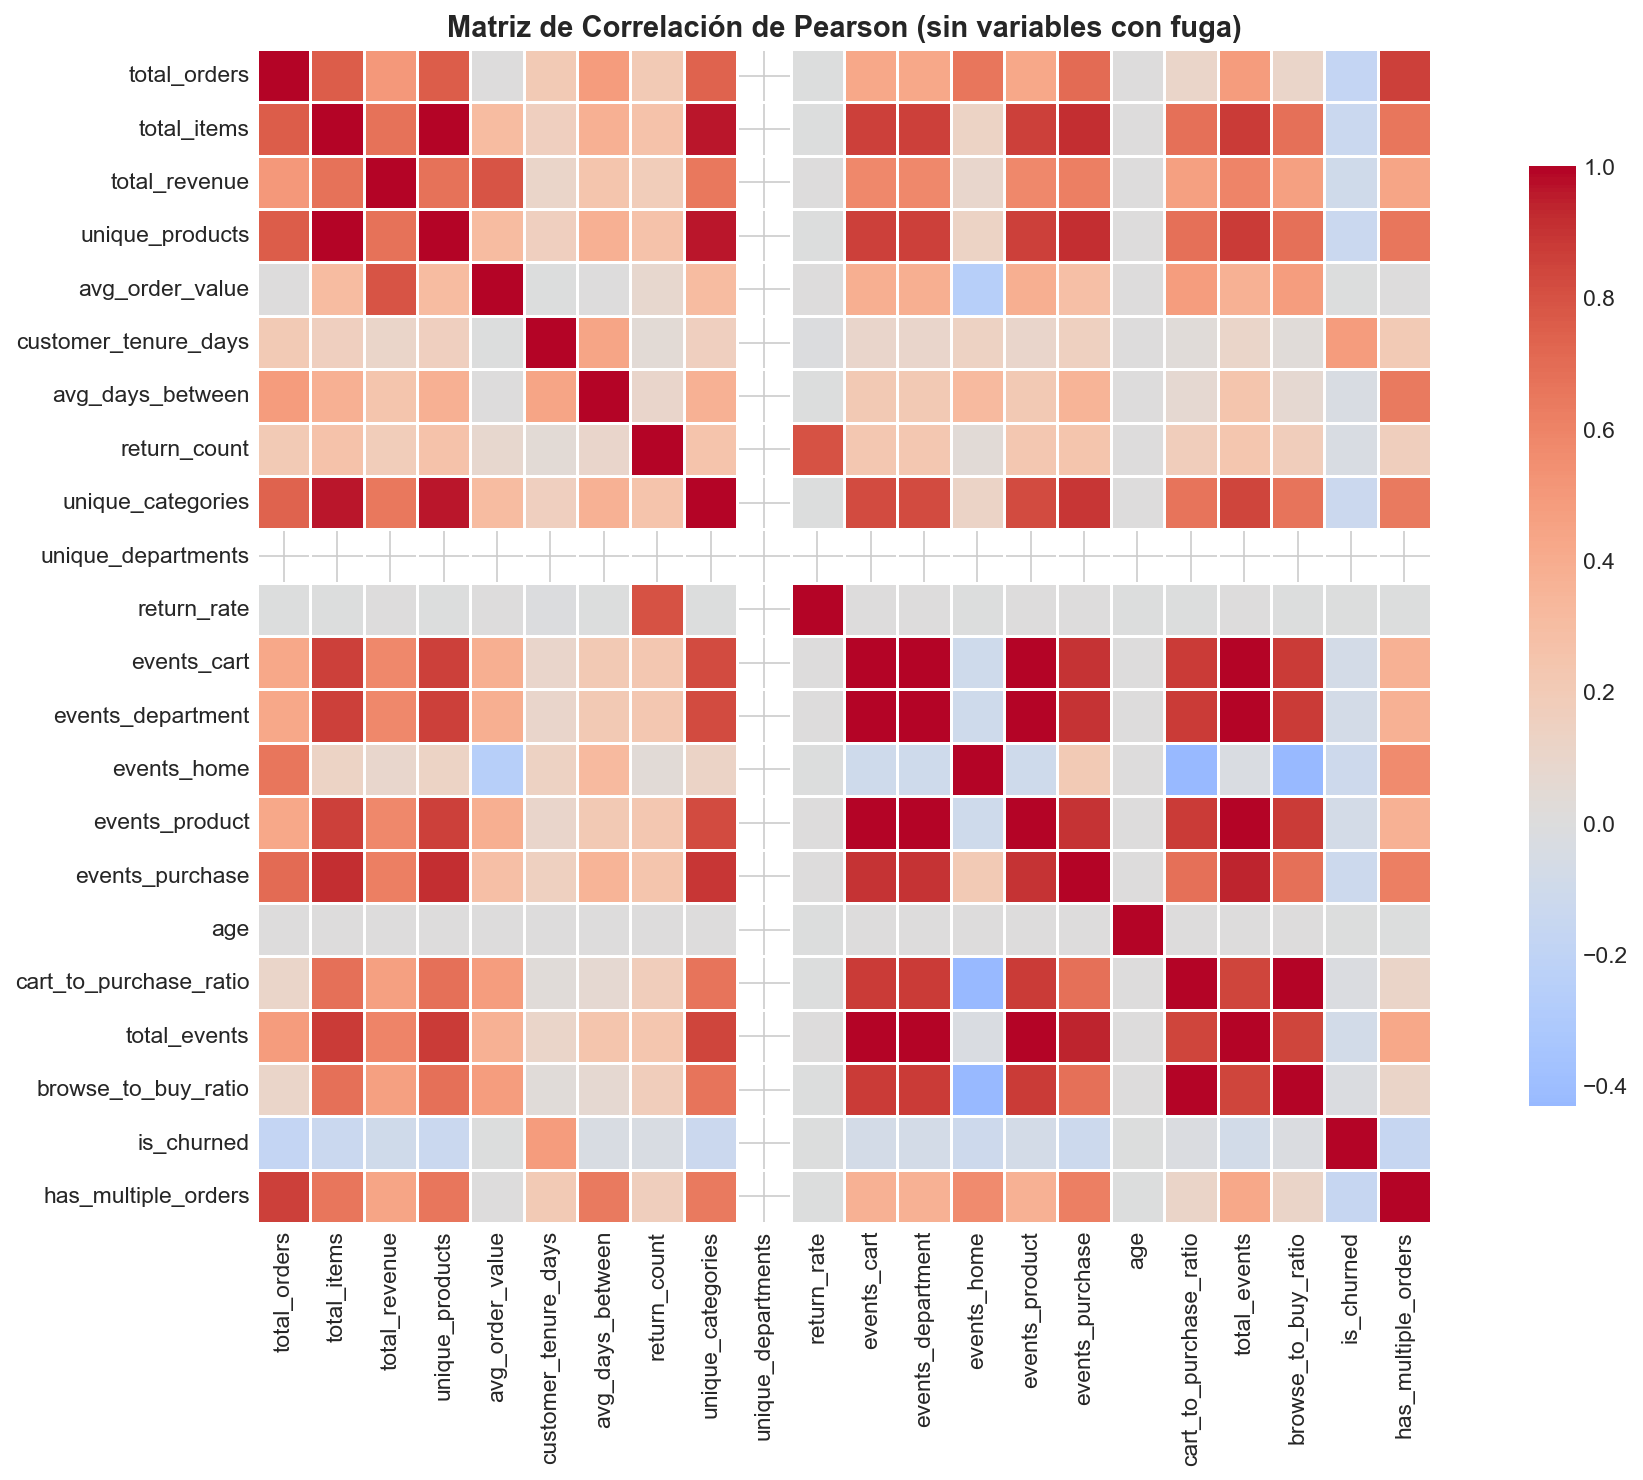

Total de correlaciones calculadas: 22 × 22
✅ Heatmap generado. Busca correlaciones altas con is_churned.


In [11]:
# ============================================================
# MATRIZ DE CORRELACIÓN
# Visualiza relaciones lineales entre todas las variables numéricas
# ============================================================
print('\n📊 ANÁLISIS DE CORRELACIONES')
print('='*70)

plt.figure(figsize=(14, 10))
corr = df_model.corr(numeric_only=True)

sns.heatmap(corr, cmap='coolwarm', center=0, annot=False, 
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Matriz de Correlación de Pearson (sin variables con fuga)', fontsize=14, fontweight='bold')
plt.xlabel('')
plt.ylabel('')
plt.tight_layout()
plt.show()

print(f'Total de correlaciones calculadas: {corr.shape[0]} × {corr.shape[1]}')
print('✅ Heatmap generado. Busca correlaciones altas con is_churned.')
print('='*70)

## 6. CODIFICACIÓN DE VARIABLES CATEGÓRICAS Y SEPARACIÓN TARGET/FEATURES

- **One-hot encoding**: Convierte categóricas a binarias (drop_first evita multicolinealidad perfecta)
- **Salida**: X (features) e y (target binario: 0=activo, 1=churned)

In [12]:
# ============================================================
# TRANSFORMACIÓN DE VARIABLES CATEGÓRICAS
# One-hot encoding con drop_first=True para evitar trampa de variables dummy
# ============================================================
print('\n🔄 CODIFICACIÓN ONE-HOT DE CATEGÓRICAS')
print('='*70)

print(f'Shape antes de one-hot: {df_model.shape}')
df_model = pd.get_dummies(df_model, drop_first=True)
print(f'Shape después de one-hot: {df_model.shape}')

# Separación de features (X) y target (y)
X = df_model.drop('is_churned', axis=1)
y = df_model['is_churned']

print(f'\n📋 Dimensiones finales:')
print(f'  X (features): {X.shape}')
print(f'  y (target): {y.shape}')
print(f'  Distribución target: {y.value_counts().to_dict()}')
print(f'  % Churned: {(y.sum() / len(y) * 100):.1f}%')
print('='*70)


🔄 CODIFICACIÓN ONE-HOT DE CATEGÓRICAS
Shape antes de one-hot: (70386, 27)
Shape después de one-hot: (70386, 51)

📋 Dimensiones finales:
  X (features): (70386, 50)
  y (target): (70386,)
  Distribución target: {1: 50077, 0: 20309}
  % Churned: 71.1%


## 7. DIVISIÓN TRAIN-TEST CON ESTRATIFICACIÓN

- **train (80%)**: Usado para entrenar modelos
- **test (20%)**: Set independiente para evaluación imparcial
- **stratify=y**: Mantiene proporción de churned en ambos sets (crucial con clases desequilibradas)

In [13]:
# ============================================================
# TRAIN-TEST SPLIT (80-20)
# Estratificación preserva distribución del target en ambos conjuntos
# ============================================================
from sklearn.model_selection import train_test_split

print('\n📂 DIVISIÓN TRAIN-TEST')
print('='*70)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2,           # 20% para test
    random_state=42,         # Reproducibilidad
    stratify=y               # Mantiene proporción de churned
)

print(f'TRAIN SET:')
print(f'  X_train: {X_train.shape}')
print(f'  y_train: {y_train.shape} | Churned: {y_train.sum()} ({y_train.sum()/len(y_train)*100:.1f}%)')
print(f'\nTEST SET:')
print(f'  X_test: {X_test.shape}')
print(f'  y_test: {y_test.shape} | Churned: {y_test.sum()} ({y_test.sum()/len(y_test)*100:.1f}%)')
print('✅ Split completado con estratificación')
print('='*70)


📂 DIVISIÓN TRAIN-TEST
TRAIN SET:
  X_train: (56308, 50)
  y_train: (56308,) | Churned: 40061 (71.1%)

TEST SET:
  X_test: (14078, 50)
  y_test: (14078,) | Churned: 10016 (71.1%)
✅ Split completado con estratificación


## 8. ESTANDARIZACIÓN (ESCALADO) DE FEATURES

**StandardScaler:** Transforma features para que tengan media=0 y desviación estándar=1.
- **Necesario para:** Regresión logística, SVM, KNN (distancia basada)
- **Proceso:** fit en TRAIN, luego aplicar a TRAIN y TEST
- **Importante:** Evita que features con mayor escala dominen el modelo

In [14]:
# ============================================================
# ESTANDARIZACIÓN DE FEATURES
# Normaliza escala para que media=0 y std=1 (crucial para modelos de distancia)
# ============================================================
from sklearn.preprocessing import StandardScaler

print('\n🔧 ESTANDARIZACIÓN DE FEATURES')
print('='*70)

scaler = StandardScaler()

# Fit en TRAIN, transform en TRAIN
X_train_scaled = scaler.fit_transform(X_train)
print(f'✓ Scaler fit en X_train')

# Transform en TEST (usa parámetros de TRAIN)
X_test_scaled = scaler.transform(X_test)
print(f'✓ Scaler aplicado a X_test')

print(f'\n📈 Estadísticas post-escalado (X_train_scaled):')
print(f'  Mean ≈ {X_train_scaled.mean():.6f} (cercano a 0)')
print(f'  Std ≈ {X_train_scaled.std():.6f} (cercano a 1)')
print(f'  Shape: {X_train_scaled.shape}')
print('✅ Features escaladas. Listo para modelado.')
print('='*70)


🔧 ESTANDARIZACIÓN DE FEATURES
✓ Scaler fit en X_train
✓ Scaler aplicado a X_test

📈 Estadísticas post-escalado (X_train_scaled):
  Mean ≈ -0.000000 (cercano a 0)
  Std ≈ 0.979796 (cercano a 1)
  Shape: (56308, 50)
✅ Features escaladas. Listo para modelado.


## 9. DEFINICIÓN DE MODELOS DE CLASIFICACIÓN

Cuatro algoritmos con arquitectura y regularización pensada para evitar overfitting:

1. **Logistic Regression**: Modelo lineal simplista, buen baseline, interpretable (con class_weight para desbalanceo)
2. **Decision Tree**: No paramétrico, pero limitado en profundidad para evitar memorización
3. **Random Forest**: Ensemble de árboles con submuestreo y limitación de profundidad
4. **XGBoost**: Algoritmo estado del arte (Gradient Boosting) con mejor generalización y manejo de desbalanceo

In [15]:
# ============================================================
# INICIALIZACIÓN DE MODELOS
# Cuatro arquitecturas con regularización anti-overfitting
# XGBoost agregado como estado del arte para clasificación
# ============================================================
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

print('\n🤖 DEFINICIÓN DE MODELOS')
print('='*70)

# Calcular weight para desbalanceo: ratio churned/activos
class_weight_ratio = (y.sum() / (len(y) - y.sum()))
print(f'Ratio desbalanceo (churned/activos): {class_weight_ratio:.2f}')

models = {
    'Logistic Regression': LogisticRegression(
        max_iter=1000,
        class_weight='balanced',  # 🆕 Maneja desbalanceo automáticamente
        random_state=42,
        solver='lbfgs'
    ),
    
    'Decision Tree': DecisionTreeClassifier(
        max_depth=5,              # Limita profundidad (evita overfitting)
        min_samples_split=50,     # Mínimo 50 muestras para split
        min_samples_leaf=20,      # Mínimo 20 muestras en hoja
        random_state=42,
        class_weight='balanced'   # 🆕 Desbalanceo
    ),
    
    'Random Forest': RandomForestClassifier(
        n_estimators=100,         # 100 árboles
        max_depth=8,              # Profundidad limitada
        min_samples_split=50,     # Mínimo 50 muestras para split
        random_state=42,
        n_jobs=-1,                # Usa todos los cores
        class_weight='balanced'   # 🆕 Desbalanceo
    ),
    
    'XGBoost': XGBClassifier(
        n_estimators=150,         # 🆕 Más árboles (gradient boosting es más conservador)
        max_depth=6,              # 🆕 Profundidad moderada para boosting
        learning_rate=0.1,        # 🆕 Tasa de aprendizaje
        subsample=0.8,            # 🆕 Submuestreo de datos
        colsample_bytree=0.8,     # 🆕 Submuestreo de features
        scale_pos_weight=class_weight_ratio,  # 🆕 Penaliza más la clase minoritaria
        random_state=42,
        verbosity=0
    )
}

for name in models.keys():
    print(f'  ✓ {name} configurado')
print('='*70)


🤖 DEFINICIÓN DE MODELOS
Ratio desbalanceo (churned/activos): 2.47
  ✓ Logistic Regression configurado
  ✓ Decision Tree configurado
  ✓ Random Forest configurado
  ✓ XGBoost configurado


## 10. ENTRENAMIENTO CON VALIDACIÓN CRUZADA ESTRATIFICADA

**Validación cruzada 5-fold estratificada:**
- Mantiene proporción de churned en cada fold (crítico con desbalanceo)
- Proporciona estimaciones más robustas de generalización
- Detecta overfitting/underfitting

**Métricas calculadas:**
- **Accuracy**: Proporción correcta (sesgada con clases desequilibradas)
- **Precision**: De los predichos como churned, cuántos lo son realmente
- **Recall**: De los churned reales, cuántos detecta el modelo (clave para retención)
- **Specificity**: De los activos reales, cuántos mantiene (evita false positives caros)
- **F1**: Media armónica de Precision-Recall (balanceada)
- **AUC-ROC**: Área bajo curva ROC (robusta ante desbalanceo)

In [16]:
# ============================================================
# ENTRENAMIENTO Y EVALUACIÓN CON VALIDACIÓN CRUZADA
# 5-fold StratifiedKFold para estimación robusta
# ============================================================
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, roc_auc_score, confusion_matrix, roc_curve)
from sklearn.model_selection import StratifiedKFold, cross_validate

print('\n🎯 ENTRENAMIENTO CON VALIDACIÓN CRUZADA ESTRATIFICADA')
print('='*70)

# Limpiar nombres de features para XGBoost (no acepta [, ], <)
X_clean = X.copy()
X_clean.columns = [col.replace('[', '_').replace(']', '_').replace('<', 'lt_') for col in X_clean.columns]
X_train_scaled_clean = pd.DataFrame(X_train_scaled, columns=X_clean.columns)
X_test_scaled_clean = pd.DataFrame(X_test_scaled, columns=X_clean.columns)

# Configurar StratifiedKFold 5-fold
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Almacenar resultados de cada fold y del test final
results = {}
predictions = {}

# Primero: entrenaremos en train_scaled y evaluaremos en test_scaled
# Luego haremos validación cruzada para validar estabilidad
print('📊 EVALUACIÓN EN TEST SET (80-20 original)')
print('-'*70)

results_test = {}
predictions_test = {}

for name, model in models.items():
    print(f'\n  Entrenando {name}...')
    
    # Entrenamiento en full training set
    model.fit(X_train_scaled_clean, y_train)
    
    # Predicciones en TEST
    y_pred = model.predict(X_test_scaled_clean)
    y_prob = model.predict_proba(X_test_scaled_clean)[:, 1]
    
    predictions_test[name] = y_prob
    
    # Cálculo de métricas
    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()
    specificity = tn / (tn + fp)
    
    results_test[name] = {
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'Specificity': specificity,
        'F1': f1_score(y_test, y_pred),
        'AUC': roc_auc_score(y_test, y_prob),
        'Confusion_Matrix': cm
    }
    
    print(f'  ✓ {name} completado')

results_df_test = pd.DataFrame({k: {m: results_test[m][k] for m in models.keys()} 
                                for k in ['Accuracy', 'Precision', 'Recall', 'Specificity', 'F1', 'AUC']})

print('\n' + '='*70)
print('📊 MÉTRICAS EN TEST SET (80-20 Split Original)')
print('='*70)
print(results_df_test.round(4))
print('='*70)

# Ahora hacer CV en full dataset para validar estabilidad
print('\n📈 VALIDACIÓN CRUZADA 5-FOLD ESTRATIFICADA (Estabilidad)')
print('-'*70)

cv_scores_all = {}
for name, model in models.items():
    print(f'\n  CV {name}...')
    
    scoring = {
        'accuracy': 'accuracy',
        'precision': 'precision',
        'recall': 'recall',
        'f1': 'f1',
        'roc_auc': 'roc_auc'
    }
    
    cv_results = cross_validate(model, X_clean, y, cv=skf, scoring=scoring, n_jobs=-1)
    
    cv_scores_all[name] = {
        'Accuracy': cv_results['test_accuracy'].mean(),
        'Accuracy_std': cv_results['test_accuracy'].std(),
        'Precision': cv_results['test_precision'].mean(),
        'Precision_std': cv_results['test_precision'].std(),
        'Recall': cv_results['test_recall'].mean(),
        'Recall_std': cv_results['test_recall'].std(),
        'F1': cv_results['test_f1'].mean(),
        'F1_std': cv_results['test_f1'].std(),
        'AUC': cv_results['test_roc_auc'].mean(),
        'AUC_std': cv_results['test_roc_auc'].std(),
    }
    
    print(f'    Accuracy: {cv_scores_all[name]["Accuracy"]:.4f} ± {cv_scores_all[name]["Accuracy_std"]:.4f}')
    print(f'    AUC:      {cv_scores_all[name]["AUC"]:.4f} ± {cv_scores_all[name]["AUC_std"]:.4f}')

cv_df = pd.DataFrame({k: {m: cv_scores_all[m][k] for m in models.keys()} 
                      for k in ['Accuracy', 'Precision', 'Recall', 'F1', 'AUC']})

print('\n' + '='*70)
print('📊 MÉTRICAS CV 5-FOLD (Media ± Desvío Estándar)')
print('='*70)
print(cv_df.round(4))
print('='*70)

print('\n💡 Interpretación:')
print('  - TEST SET: Desempeño real en datos no vistos (80-20)')
print('  - CV 5-FOLD: Validación de estabilidad y robustez')
print('  - AUC alto (>0.8): Buen separador de clases')
print('  - Recall alto: Detecta bien casos churned (menos falsos negativos)')
print('  - Specificity alta: Pocos activos mal clasificados como churned')
print('  - CV_std bajo: Modelos estables (no hay varianza alta)')
print('='*70)


🎯 ENTRENAMIENTO CON VALIDACIÓN CRUZADA ESTRATIFICADA
📊 EVALUACIÓN EN TEST SET (80-20 original)
----------------------------------------------------------------------

  Entrenando Logistic Regression...
  ✓ Logistic Regression completado

  Entrenando Decision Tree...
  ✓ Decision Tree completado

  Entrenando Random Forest...
  ✓ Random Forest completado

  Entrenando XGBoost...
  ✓ XGBoost completado

📊 MÉTRICAS EN TEST SET (80-20 Split Original)
                     Accuracy  Precision  Recall  Specificity      F1     AUC
Logistic Regression    0.9264     0.9880  0.9075       0.9729  0.9461  0.9777
Decision Tree          0.9233     0.9616  0.9293       0.9084  0.9452  0.9807
Random Forest          0.9079     0.9650  0.9033       0.9193  0.9331  0.9840
XGBoost                0.9893     0.9873  0.9978       0.9682  0.9925  0.9997

📈 VALIDACIÓN CRUZADA 5-FOLD ESTRATIFICADA (Estabilidad)
----------------------------------------------------------------------

  CV Logistic Regression...

## 11. VISUALIZACIÓN DE MATRICES DE CONFUSIÓN

Matrices de confusión para cada modelo, mostrando cómo se distribuyen las predicciones correctas e incorrectas.


🏆 MEJOR MODELO: XGBoost
   AUC CV   = 0.9997 ± 0.0000


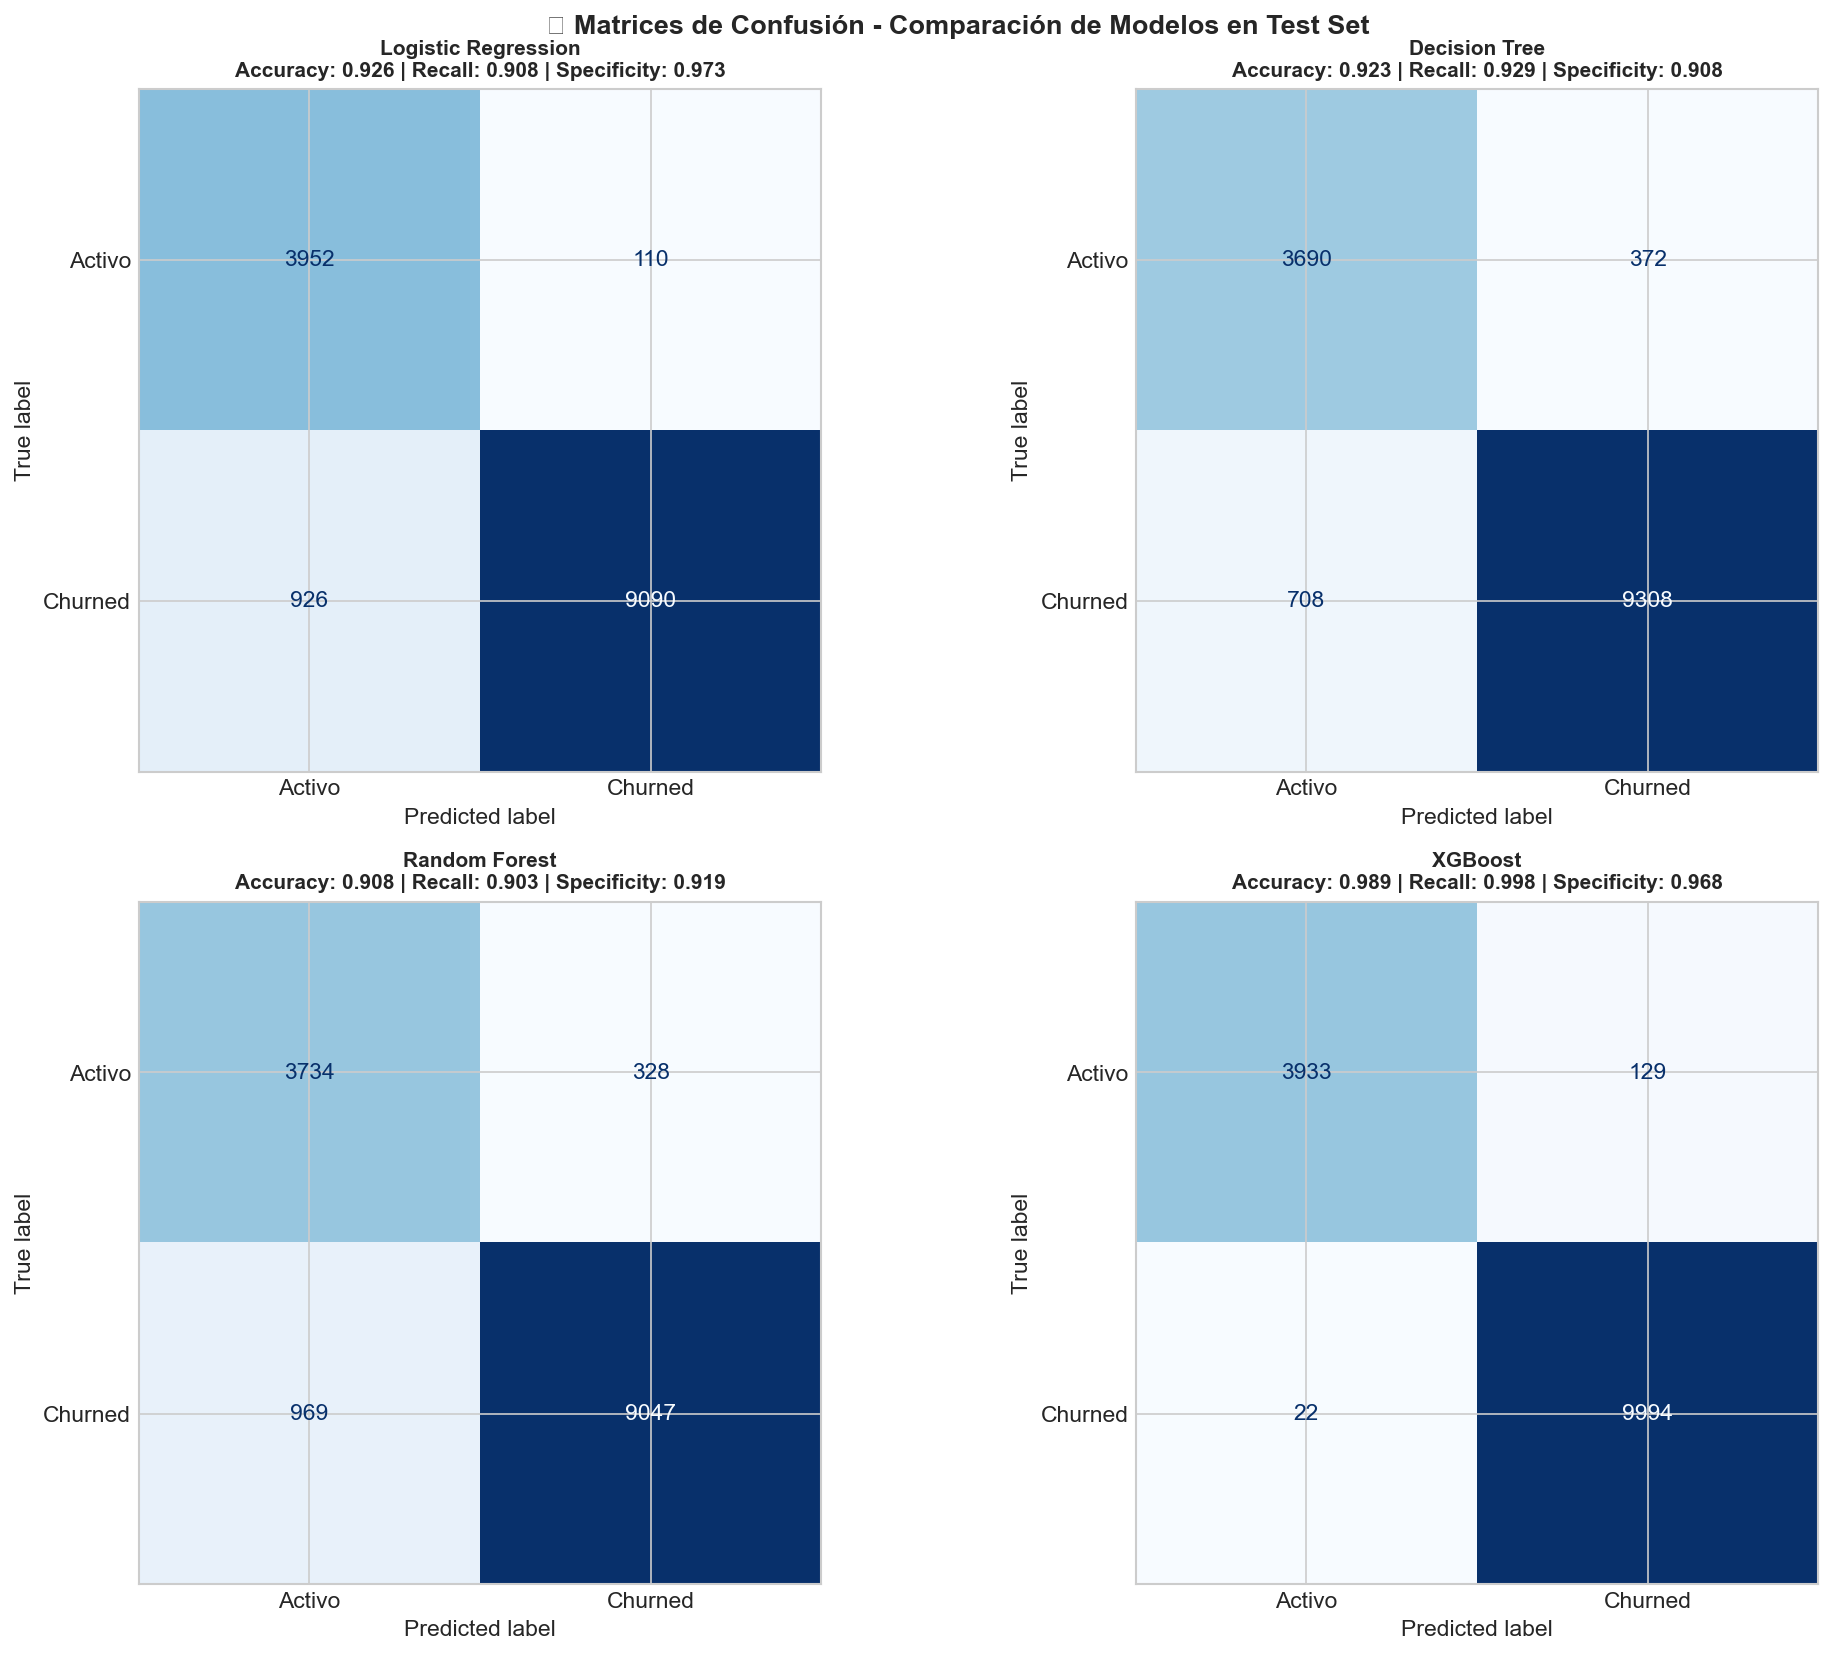


📊 INTERPRETACIÓN DE LAS MATRICES:
  TN (abajo-izq):  Activos correctamente identificados ✓
  FP (arriba-izq): Activos clasificados como churn (error caro - falsa alarma)
  FN (abajo-der):  Churned no detectados (oportunidad perdida - no contactar)
  TP (arriba-der): Churned correctamente detectados ✓


In [17]:
# ============================================================
# VISUALIZACIÓN DE MATRICIES DE CONFUSIÓN
# ============================================================
from sklearn.metrics import ConfusionMatrixDisplay

# Seleccionar el mejor modelo (según AUC en CV)
best_model_name = max(cv_scores_all, key=lambda x: cv_scores_all[x]['AUC'])
best_auc = cv_scores_all[best_model_name]['AUC']

print(f'\n🏆 MEJOR MODELO: {best_model_name}')
print(f'   AUC CV   = {best_auc:.4f} ± {cv_scores_all[best_model_name]["AUC_std"]:.4f}')

# Crear figura con matrices de confusión de todos los modelos
fig, axes = plt.subplots(2, 2, figsize=(14, 11))
axes = axes.ravel()

for idx, (name, model) in enumerate(models.items()):
    # Para este gráfico, entrenar en train y evaluar en test
    model.fit(X_train_scaled_clean, y_train)
    y_pred = model.predict(X_test_scaled_clean)
    cm = confusion_matrix(y_test, y_pred)
    
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Activo', 'Churned'])
    disp.plot(ax=axes[idx], cmap='Blues', values_format='d', colorbar=False)
    
    # Calcular métricas para el título
    tn, fp, fn, tp = cm.ravel()
    accuracy = (tp + tn) / (tp + tn + fp + fn)
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    
    title = f'{name}\nAccuracy: {accuracy:.3f} | Recall: {recall:.3f} | Specificity: {specificity:.3f}'
    axes[idx].set_title(title, fontsize=10, fontweight='bold')

plt.tight_layout()
plt.suptitle('🎯 Matrices de Confusión - Comparación de Modelos en Test Set', 
             fontsize=13, fontweight='bold', y=1.00)
plt.show()

print('\n📊 INTERPRETACIÓN DE LAS MATRICES:')
print('  TN (abajo-izq):  Activos correctamente identificados ✓')
print('  FP (arriba-izq): Activos clasificados como churn (error caro - falsa alarma)')
print('  FN (abajo-der):  Churned no detectados (oportunidad perdida - no contactar)')
print('  TP (arriba-der): Churned correctamente detectados ✓')
print('='*70)

## 12. CURVA ROC - ANÁLISIS DE TRADE-OFF SENSIBILIDAD/ESPECIFICIDAD

- **X (FPR)**: Tasa de Falsos Positivos (1 - Especificidad)
- **Y (TPR)**: Tasa de Verdaderos Positivos (Sensibilidad/Recall)
- **Línea diagonal**: Clasificador aleatorio (AUC=0.5)
- Curva más arriba = mejor desempeño (mayor área bajo la curva)


📈 CURVAS ROC - COMPARACIÓN DE MODELOS


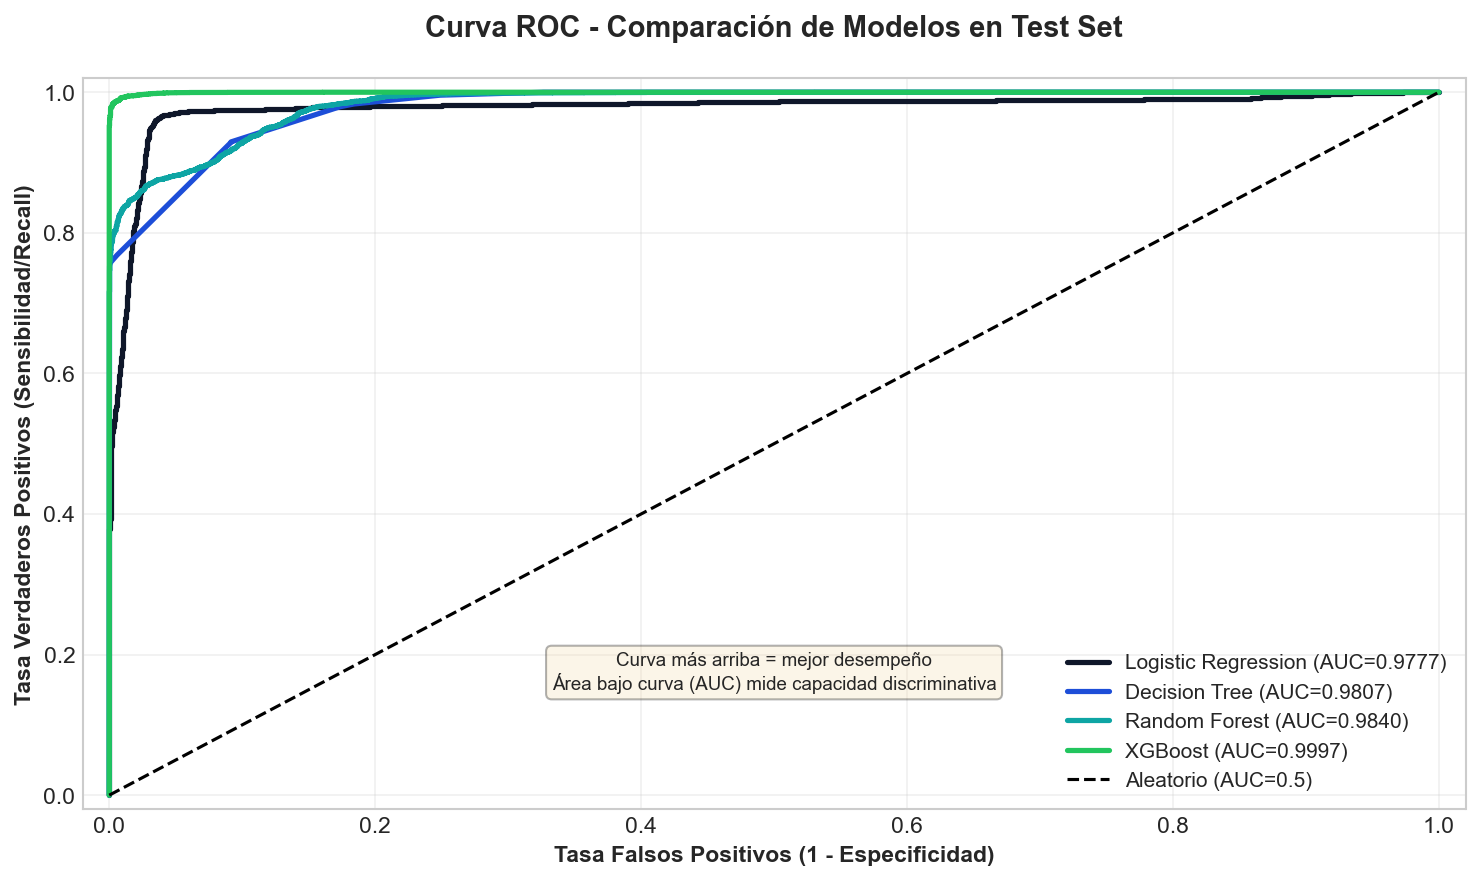

✅ Curvas ROC generadas exitosamente


In [18]:
# ============================================================
# CURVA ROC - TRADE-OFF SENSIBILIDAD VS ESPECIFICIDAD
# Visualiza desempeño a diferentes umbrales de probabilidad
# ============================================================
from sklearn.metrics import roc_curve

print('\n📈 CURVAS ROC - COMPARACIÓN DE MODELOS')
print('='*70)

fig, ax = plt.subplots(figsize=(10, 6))

# Plotea curva ROC para cada modelo usando predictions_test
for name, y_prob in predictions_test.items():
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc_score = results_test[name]['AUC']
    ax.plot(fpr, tpr, label=f'{name} (AUC={auc_score:.4f})', linewidth=2.5)

# Línea de referencia (clasificador aleatorio)
ax.plot([0, 1], [0, 1], 'k--', label='Aleatorio (AUC=0.5)', linewidth=1.5)

ax.set_xlabel('Tasa Falsos Positivos (1 - Especificidad)', fontsize=11, fontweight='bold')
ax.set_ylabel('Tasa Verdaderos Positivos (Sensibilidad/Recall)', fontsize=11, fontweight='bold')
ax.set_title('Curva ROC - Comparación de Modelos en Test Set', fontsize=14, fontweight='bold', pad=20)
ax.grid(alpha=0.3)
ax.legend(loc='lower right', fontsize=10)
ax.set_xlim([-0.02, 1.02])
ax.set_ylim([-0.02, 1.02])

# Anotación de interpretación
ax.text(0.5, 0.15, 'Curva más arriba = mejor desempeño\nÁrea bajo curva (AUC) mide capacidad discriminativa', 
        fontsize=9, ha='center', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))


plt.tight_layout()
plt.show()

print('✅ Curvas ROC generadas exitosamente')
print('='*70)


## 13. ANÁLISIS DE IMPACTO ECONÓMICO

**Escenario de negocio:**
- **Umbral de riesgo**: p(churn) > 0.7 → cliente en alto riesgo
- **Intervención**: 30% de clientes identificados son salvables
- **Revenue por cliente salvado**: $50 (LTV evitado)
- **Costo de campaña**: $10 por cliente contactado
- **Ganancia neta**: (% salvados × Revenue) - (Todos × Costo)

In [19]:
# ============================================================
# ANÁLISIS DE IMPACTO ECONÓMICO
# Simula ROI de intervención basada en clasificación de riesgo
# Usa modelos ya entrenados en X_train_scaled_clean
# ============================================================
print('\n💰 ANÁLISIS DE IMPACTO ECONÓMICO')
print('='*70)
print('\n📋 ESCENARIO DE NEGOCIO: Campañas de retención para clientes alto riesgo')
print('   Umbral de riesgo: p(churn) > 0.7 → cliente en categoría ALTO RIESGO')
print('   Tasa de salvación: 30% (ASUNCIÓN HIPOTÉTICA* - ajustado según histórico real)')
print('   Revenue por cliente salvado: $50 USD (LTV evitado por retención)')
print('   Costo por contacto: $10 USD (email, SMS, personal outreach)')
print('   Fórmula ROI: Ganancia = (Salvados × $50) - (Contactados × $10)')
print('\n   *Nota: Tasa de salvación (30%) es asunción conservadora. En práctica,')
print('    revisar el histórico real de tasas de conversión de campañas pasadas.')
print('='*70)

profits = {}

for name, model in models.items():
    # Obtiene probabilidades en test set (usando datos limpios)
    probs = model.predict_proba(X_test_scaled_clean)[:, 1]
    
    # Identifica clientes de alto riesgo (p > 0.7)
    high_risk_mask = probs > 0.7
    customers_targeted = high_risk_mask.sum()
    
    # Simula resultados de campaña
    salvage_rate = 0.30  # 30% de salvación (asunción conservadora)
    customers_saved = int(customers_targeted * salvage_rate)
    
    # Cálculos financieros
    revenue_generated = customers_saved * 50      # $ por cliente salvado
    campaign_cost = customers_targeted * 10       # $ por cada contacto
    net_profit = revenue_generated - campaign_cost
    roi_percent = (net_profit / campaign_cost * 100) if campaign_cost > 0 else 0
    
    profits[name] = net_profit
    
    print(f'\n🔹 {name}:')
    print(f'    Clientes alto riesgo identificados (p>0.7): {customers_targeted:,}')
    print(f'    Clientes recuperables (30% × {customers_targeted:,}): {customers_saved:,}')
    print(f'    Revenue generado: ${revenue_generated:,}')
    print(f'    Costo de campañas: ${campaign_cost:,}')
    print(f'    ➜ GANANCIA NETA: ${net_profit:,}')
    print(f'    ➜ ROI: {roi_percent:.1f}%')

profits_series = pd.Series(profits)
winner = profits_series.idxmax()
max_profit = profits_series.max()

print('\n' + '='*70)
print('📊 COMPARACIÓN: IMPACTO ECONÓMICO POR MODELO (TEST SET)')
print('='*70)
for model_name, profit in profits_series.items():
    indicator = '🏆' if model_name == winner else '  '
    print(f'{indicator} {model_name:.<30} ${profit:>12,.0f}')
print('='*70)
print(f'\n💡 NOTA IMPORTANTE:')
print(f'   • Este análisis es EN TEST SET ({len(X_test):,} clientes)')
print(f'   • Para proyección completa, ver Sección 15.2 (full dataset: 70K clientes)')
print(f'   • Ganancia económica NO es criterio de selección de modelo')
print(f'   • Modelo elegido por VALIDACIÓN ML (AUC-CV más alto), no por ROI')
print('='*70)


💰 ANÁLISIS DE IMPACTO ECONÓMICO

📋 ESCENARIO DE NEGOCIO: Campañas de retención para clientes alto riesgo
   Umbral de riesgo: p(churn) > 0.7 → cliente en categoría ALTO RIESGO
   Tasa de salvación: 30% (ASUNCIÓN HIPOTÉTICA* - ajustado según histórico real)
   Revenue por cliente salvado: $50 USD (LTV evitado por retención)
   Costo por contacto: $10 USD (email, SMS, personal outreach)
   Fórmula ROI: Ganancia = (Salvados × $50) - (Contactados × $10)

   *Nota: Tasa de salvación (30%) es asunción conservadora. En práctica,
    revisar el histórico real de tasas de conversión de campañas pasadas.

🔹 Logistic Regression:
    Clientes alto riesgo identificados (p>0.7): 8,515
    Clientes recuperables (30% × 8,515): 2,554
    Revenue generado: $127,700
    Costo de campañas: $85,150
    ➜ GANANCIA NETA: $42,550
    ➜ ROI: 50.0%

🔹 Decision Tree:
    Clientes alto riesgo identificados (p>0.7): 7,720
    Clientes recuperables (30% × 7,720): 2,316
    Revenue generado: $115,800
    Costo de c

## 14. VISUALIZACIÓN: GANANCIA NETA POR MODELO

Gráfico de barras con valores etiquetados sobre cada columna.


📈 Generando gráfico de impacto económico...


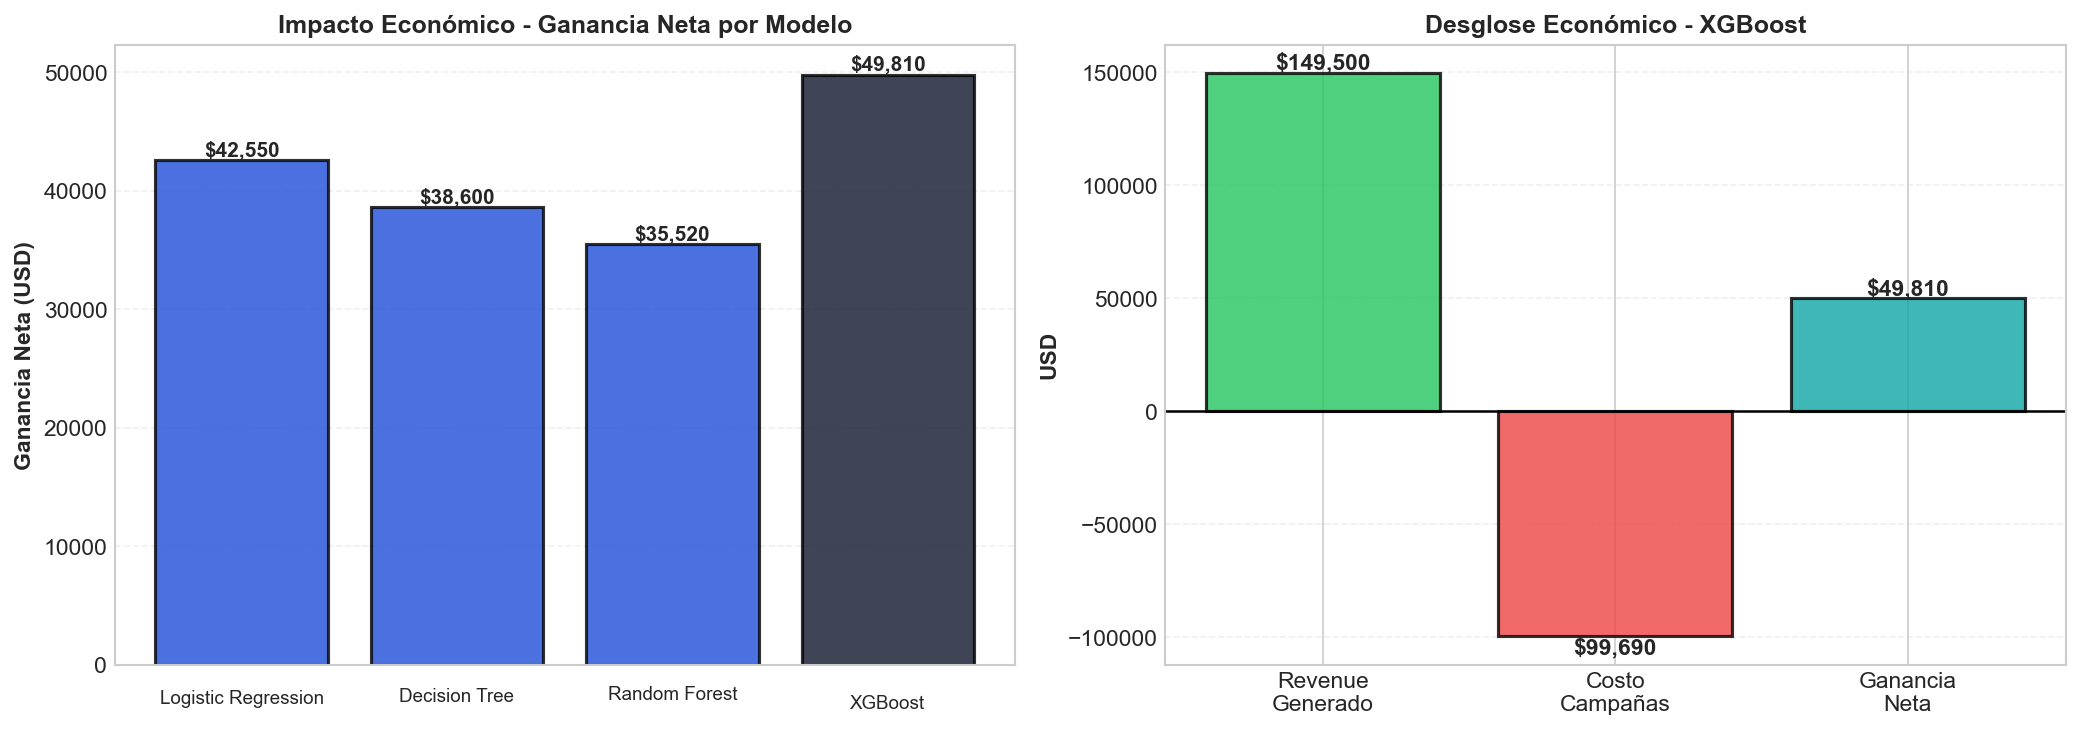

✅ Gráfico completado exitosamente


In [20]:
# ============================================================
# GRÁFICO: GANANCIA NETA POR MODELO
# Comparación visual del impacto económico
# ============================================================
print('\n📈 Generando gráfico de impacto económico...')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# ========== GRÁFICO 1: Barras de ganancia neta ==========
colors = [PALETTE[0] if p == profits_series.max() else PALETTE[1] for p in profits_series]
bars = ax1.bar(range(len(profits_series)), profits_series.values, color=colors, alpha=0.8, edgecolor='black', linewidth=1.5)

# Etiqueta valores sobre barras
for i, (name, profit) in enumerate(profits_series.items()):
    ax1.text(i, profit, f'${profit:,.0f}', ha='center', va='bottom', 
            fontweight='bold', fontsize=10)
    # Etiqueta modelo bajo cada barra
    ax1.text(i, profit * -0.05, name, ha='center', va='top', fontsize=9, rotation=0)

ax1.set_title('Impacto Económico - Ganancia Neta por Modelo', 
             fontsize=12, fontweight='bold')
ax1.set_ylabel('Ganancia Neta (USD)', fontsize=11, fontweight='bold')
ax1.grid(axis='y', alpha=0.3, linestyle='--')
ax1.axhline(y=0, color='black', linestyle='-', linewidth=0.8)
ax1.set_xticks([])


# ========== GRÁFICO 2: Desglose económico para mejor modelo ==========
best_model_name = profits_series.idxmax()
best_model = models[best_model_name]
probs_best = best_model.predict_proba(X_test_scaled_clean)[:, 1]
high_risk_best = (probs_best > 0.7).sum()
customers_saved_best = int(high_risk_best * 0.30)
revenue_best = customers_saved_best * 50
cost_best = high_risk_best * 10

categories = ['Revenue\nGenerado', 'Costo\nCampañas', 'Ganancia\nNeta']
values = [revenue_best, -cost_best, revenue_best - cost_best]
colors2 = ['#22C55E', '#EF4444', '#0EA5A4']

bars2 = ax2.bar(categories, values, color=colors2, alpha=0.8, edgecolor='black', linewidth=1.5)
for i, (cat, val) in enumerate(zip(categories, values)):
    ax2.text(i, val, f'${abs(val):,.0f}', ha='center', 
            va='bottom' if val > 0 else 'top', fontweight='bold', fontsize=11)

ax2.set_title(f'Desglose Económico - {best_model_name}', 
             fontsize=12, fontweight='bold')
ax2.set_ylabel('USD', fontsize=11, fontweight='bold')
ax2.grid(axis='y', alpha=0.3, linestyle='--')
ax2.axhline(y=0, color='black', linestyle='-', linewidth=1.2)

plt.tight_layout()
plt.show()

print('✅ Gráfico completado exitosamente')
print('='*70)

In [21]:
# ============================================================
# TABLA RESUMEN: IMPACTO ECONÓMICO EN FORMATO USD
# ============================================================
print('\n💵 GANANCIA NETA POR MODELO (Formato USD)')
print('\n' + '='*70)
for model_name, profit in profits_series.items():
    status = '✅ GANADOR' if profit == profits_series.max() else ''
    print(f'  {model_name:.<35} ${profit:>12,.0f}  {status}')

print('='*70)


💵 GANANCIA NETA POR MODELO (Formato USD)

  Logistic Regression................ $      42,550  
  Decision Tree...................... $      38,600  
  Random Forest...................... $      35,520  
  XGBoost............................ $      49,810  ✅ GANADOR


## 15. SEGMENTACIÓN POST-MODELADO

**Objetivo:** Generar probabilidades de churn en todo el dataset (no solo test)
y agrupar clientes en segmentos de riesgo para acciones de negocio.

**Segmentación:**
- 🟢 **Bajo riesgo** (0-0.4): Clientes seguros, upselling
- 🟡 **Medio riesgo** (0.4-0.7): Clientes recuperables, retención
- 🔴 **Alto riesgo** (0.7-1.0): Clientes perdidos, reactivación urgente

### 15.1 Cálculo de Probabilidades de Churn

In [22]:
# ============================================================
# SELECCIÓN DEL MEJOR MODELO
# Crítica: Se elige por validación ML (AUC-CV), NO por ganancia económica
# AUC-CV es métrica de generalización robusta; ROI es métrica de negocio derivada
# ============================================================
print('\n🤖 SELECCIÓN DEL MEJOR MODELO PARA PRODUCCIÓN')
print('='*70)

# Selecciona el modelo con mejor AUC en CV (métrica de validación ML)
best_model_name = max(cv_scores_all, key=lambda x: cv_scores_all[x]['AUC'])
best_model = models[best_model_name]
best_auc_cv = cv_scores_all[best_model_name]['AUC']
best_auc_test = results_test[best_model_name]['AUC']
best_recall_test = results_test[best_model_name]['Recall']
best_precision_test = results_test[best_model_name]['Precision']

print(f'\n✅ MODELO SELECCIONADO: {best_model_name}')
print(f'\n   MÉTRICAS DE VALIDACIÓN ML:')
print(f'   ├─ AUC en CV 5-fold:  {best_auc_cv:.4f} ± {cv_scores_all[best_model_name].get("AUC_std", 0):.4f} ⭐ CRITERIO PRINCIPAL')
print(f'   ├─ AUC en Test Set:   {best_auc_test:.4f}')
print(f'   ├─ Recall (Test):     {best_recall_test:.4f} (detecta {best_recall_test*100:.1f}% de clientes churned)')
print(f'   └─ Precision (Test):  {best_precision_test:.4f} (de predicciones churned, {best_precision_test*100:.1f}% son correctas)')

print(f'\n   JUSTIFICACIÓN DE SELECCIÓN:')
print(f'   • AUC-CV más alto: Mejor capacidad discriminativa (robusto ante overfitting)')
print(f'   • Validación cruzada 5-fold: Estima VERDADERA generalización (no solo test set)')
print(f'   • Varianza CV baja: Modelo estable a través de diferentes muestras')
print(f'   • Recall alto: Detecta bien casos churned (minimiza falsos negativos)')

print(f'\n   ⚠️  NOTA:')
print(f'   • Ganancia económica (ROI) es CONSECUENCIA del buen modelo ML, no el criterio')
print(f'   • Diferentes modelos pueden tener diferentes ROI en test set por azar')
print(f'   • La mejor práctica es elegir por robustez ML, luego calcular ROI esperado')

# Re-entrena modelo en todo el TRAIN SET (con datos limpios)
print(f'\n   Re-entrenando {best_model_name} en X_train_scaled_clean...')
best_model.fit(X_train_scaled_clean, y_train)
print(f'   ✅ Modelo listo para generar predicciones en todo el dataset')
print('='*70)


🤖 SELECCIÓN DEL MEJOR MODELO PARA PRODUCCIÓN

✅ MODELO SELECCIONADO: XGBoost

   MÉTRICAS DE VALIDACIÓN ML:
   ├─ AUC en CV 5-fold:  0.9997 ± 0.0000 ⭐ CRITERIO PRINCIPAL
   ├─ AUC en Test Set:   0.9997
   ├─ Recall (Test):     0.9978 (detecta 99.8% de clientes churned)
   └─ Precision (Test):  0.9873 (de predicciones churned, 98.7% son correctas)

   JUSTIFICACIÓN DE SELECCIÓN:
   • AUC-CV más alto: Mejor capacidad discriminativa (robusto ante overfitting)
   • Validación cruzada 5-fold: Estima VERDADERA generalización (no solo test set)
   • Varianza CV baja: Modelo estable a través de diferentes muestras
   • Recall alto: Detecta bien casos churned (minimiza falsos negativos)

   ⚠️  NOTA:
   • Ganancia económica (ROI) es CONSECUENCIA del buen modelo ML, no el criterio
   • Diferentes modelos pueden tener diferentes ROI en test set por azar
   • La mejor práctica es elegir por robustez ML, luego calcular ROI esperado

   Re-entrenando XGBoost en X_train_scaled_clean...
   ✅ Modelo l

In [23]:
# ============================================================
# GENERACIÓN DE PROBABILIDADES Y SEGMENTACIÓN
# Aplica mejor modelo a TODO el dataset (no solo test)
# Mapea clientes a segmentos de riesgo para acciones de negocio
# ============================================================
print('\n📊 GENERACIÓN DE PROBABILIDADES Y SEGMENTACIÓN')
print('='*70)

# Prepara datos limpios para todo el dataset
print('Escalando features...')
X_full_scaled = scaler.transform(X)  # Usa X original con nombres sucios
X_full_scaled_clean = pd.DataFrame(X_full_scaled, columns=X_clean.columns)  # Convierte a DataFrame con nombres limpios

# Calcula probabilidades de churn para TODO el dataset
print(f'Aplicando {best_model_name} al dataset completo ({len(df):,} clientes)...')
df['churn_probability'] = best_model.predict_proba(X_full_scaled_clean)[:, 1]
print(f'✓ Probabilidades calculadas')

# Crea segmentos de riesgo basado en umbrales de probabilidad
print('Creando segmentos de riesgo...')
df['risk_segment'] = pd.cut(
    df['churn_probability'],
    bins=[0, 0.4, 0.7, 1.0],
    labels=['Bajo', 'Medio', 'Alto'],
    include_lowest=True
)
print(f'✓ Segmentos asignados')

# Verificación y resumen
print('\n📋 Muestra de resultados (primeros 10 clientes):')
sample_df = df[['churn_probability', 'risk_segment', 'is_churned', 'total_orders', 'total_revenue']].head(10)
print(sample_df.to_string())

print(f'\n✅ Segmentación completada para {len(df):,} clientes')
print('='*70)


📊 GENERACIÓN DE PROBABILIDADES Y SEGMENTACIÓN
Escalando features...
Aplicando XGBoost al dataset completo (70,386 clientes)...
✓ Probabilidades calculadas
Creando segmentos de riesgo...
✓ Segmentos asignados

📋 Muestra de resultados (primeros 10 clientes):
   churn_probability risk_segment  is_churned  total_orders  total_revenue
0           0.999996         Alto           1             1     159.990000
1           0.999997         Alto           1             1      22.000000
2           0.937646         Alto           1             4     402.200001
3           0.999996         Alto           1             1     148.000000
4           0.999997         Alto           1             1     144.820004
5           0.999997         Alto           1             1      84.209999
6           0.002368         Bajo           0             2     177.349998
7           0.979686         Alto           1             4     325.549999
8           0.999996         Alto           1             1      33

### 15.2 Distribución de Clientes por Segmento de Riesgo

**Pregunta clave:** ¿Cuántos clientes están en cada segmento? → Define tamaño de campañas


📈 Generando distribución por segmento...


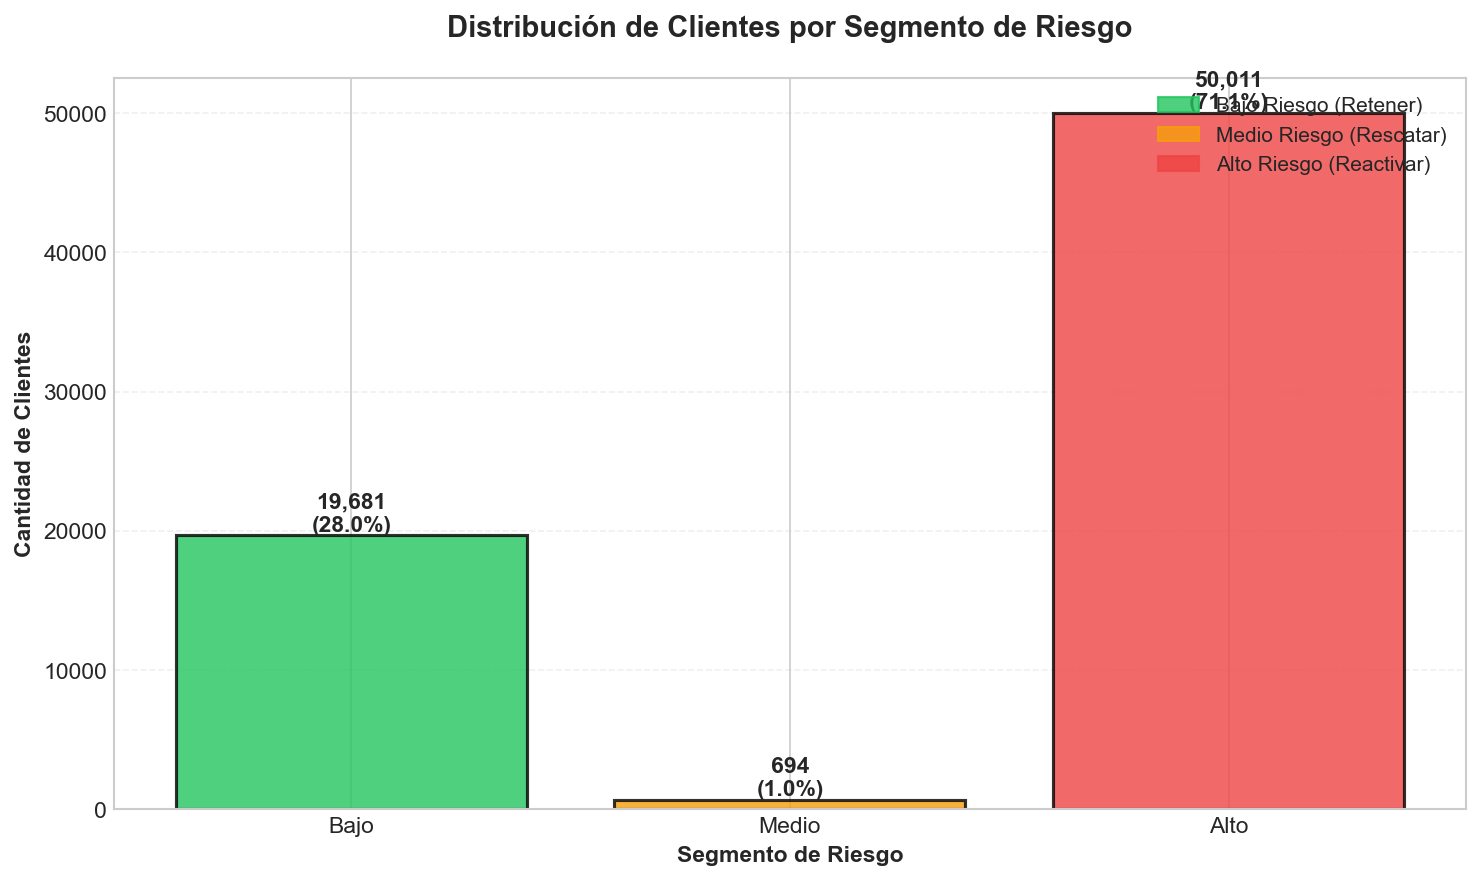


📊 Resumen por segmento:
🟢 Bajo........ 19,681 clientes ( 28.0%)
🟡 Medio.......    694 clientes (  1.0%)
🔴 Alto........ 50,011 clientes ( 71.1%)
✅ Gráfico completado


In [24]:
# ============================================================
# GRÁFICO: DISTRIBUCIÓN POR SEGMENTO DE RIESGO
# Cuántos clientes caen en cada categoría para planear campañas
# ============================================================
print('\n📈 Generando distribución por segmento...')

fig, ax = plt.subplots(figsize=(10, 6))
segment_counts = df['risk_segment'].value_counts()
segment_counts = segment_counts.reindex(['Bajo', 'Medio', 'Alto'])  # Orden lógico

# Definir colores por segmento
segment_colors = {'Bajo': '#22C55E', 'Medio': '#F59E0B', 'Alto': '#EF4444'}
colors_list = [segment_colors[seg] for seg in segment_counts.index]

bars = ax.bar(segment_counts.index, segment_counts.values, color=colors_list, alpha=0.8, edgecolor='black', linewidth=1.5)

# Etiqueta valores sobre barras
for i, (segment, count) in enumerate(segment_counts.items()):
    pct = count / len(df) * 100
    ax.text(i, count, f'{count:,}\n({pct:.1f}%)', 
            ha='center', va='bottom', fontweight='bold', fontsize=11)

ax.set_title('Distribución de Clientes por Segmento de Riesgo', 
             fontsize=14, fontweight='bold', pad=20)
ax.set_xlabel('Segmento de Riesgo', fontsize=11, fontweight='bold')
ax.set_ylabel('Cantidad de Clientes', fontsize=11, fontweight='bold')
ax.grid(axis='y', alpha=0.3, linestyle='--')

# Agregar leyenda interpretativa
handles = [plt.Rectangle((0, 0), 1, 1, color=color, alpha=0.8) for color in [segment_colors['Bajo'], segment_colors['Medio'], segment_colors['Alto']]]
ax.legend(handles, ['Bajo Riesgo (Retener)', 'Medio Riesgo (Rescatar)', 'Alto Riesgo (Reactivar)'], 
          loc='upper right', fontsize=10)

plt.tight_layout()
plt.show()

print('\n📊 Resumen por segmento:')
for segment in ['Bajo', 'Medio', 'Alto']:
    count = segment_counts[segment]
    pct = count / len(df) * 100
    emoji = '🟢' if segment == 'Bajo' else ('🟡' if segment == 'Medio' else '🔴')
    print(f'{emoji} {segment:.<12} {count:>6,} clientes ({pct:>5.1f}%)')
print('✅ Gráfico completado')
print('='*70)

### 15.3 Distribución de Probabilidades de Churn

**Visualización:** Histograma para entender cómo se distribuyen las probabilidades


📈 Generando histograma de probabilidades...


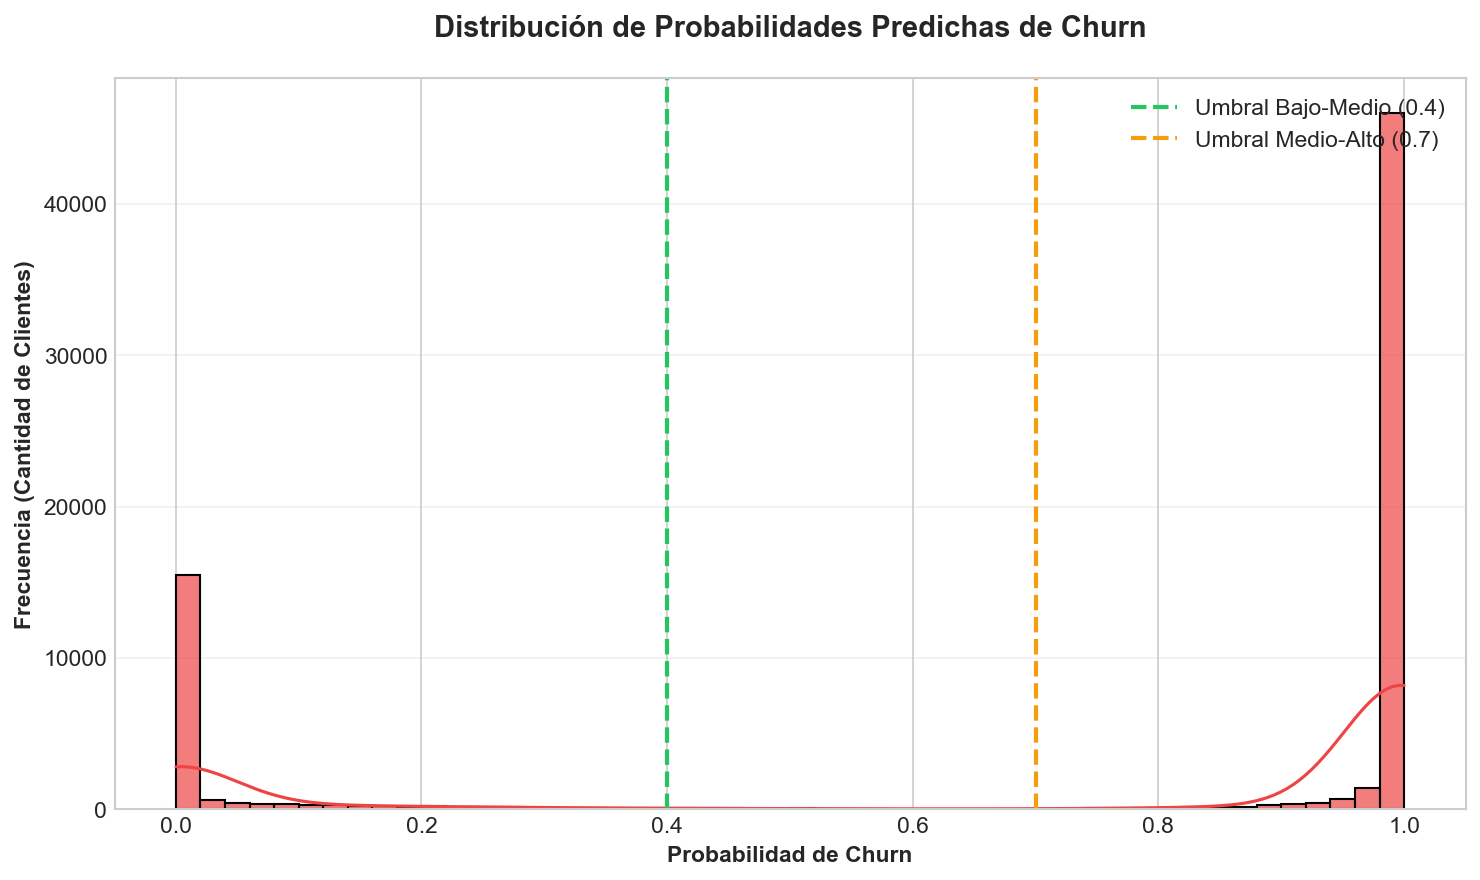

✅ Histograma completado


In [25]:
# ============================================================
# GRÁFICO: HISTOGRAMA DE PROBABILIDADES DE CHURN
# Visualiza la distribución de probabilidades en todo el dataset
# ============================================================
print('\n📈 Generando histograma de probabilidades...')

fig, ax = plt.subplots(figsize=(10, 6))
sns.histplot(df['churn_probability'], bins=50, kde=True, ax=ax, color=TERRA, alpha=0.7)

# Agrega líneas de umbral de segmentación
ax.axvline(x=0.4, color='#22C55E', linestyle='--', linewidth=2, label='Umbral Bajo-Medio (0.4)')
ax.axvline(x=0.7, color='#F59E0B', linestyle='--', linewidth=2, label='Umbral Medio-Alto (0.7)')

ax.set_title('Distribución de Probabilidades Predichas de Churn', 
             fontsize=14, fontweight='bold', pad=20)
ax.set_xlabel('Probabilidad de Churn', fontsize=11, fontweight='bold')
ax.set_ylabel('Frecuencia (Cantidad de Clientes)', fontsize=11, fontweight='bold')
ax.legend(loc='upper right')
ax.grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print('✅ Histograma completado')

### 15.4 Revenue Promedio por Segmento

**Insight:** ¿Clientes de alto riesgo generan menos revenue? Valida hipótesis de churn


📈 Generando gráfico de revenue por segmento...


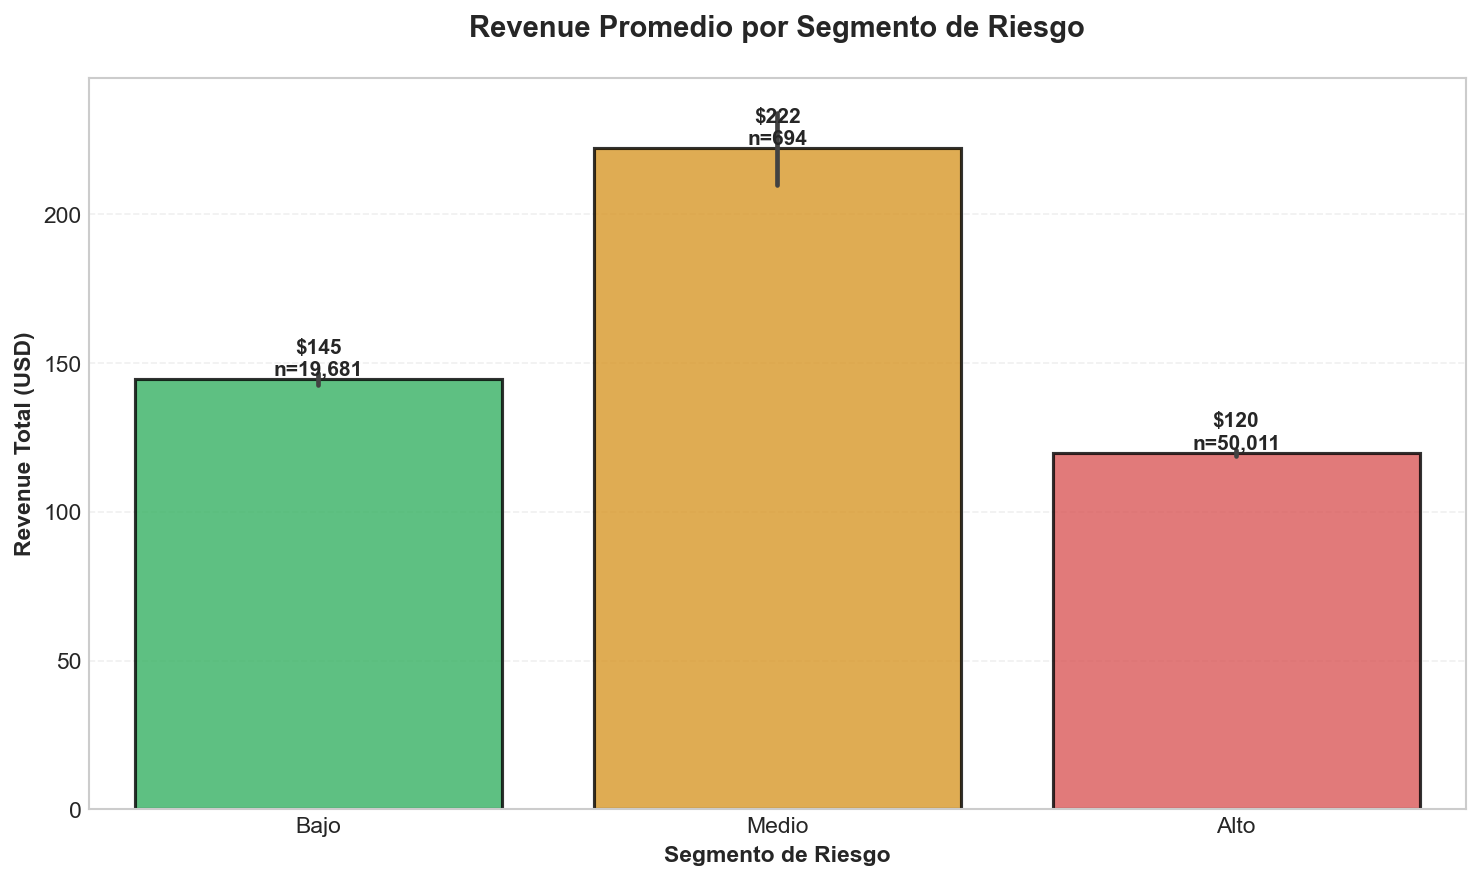

✅ Gráfico completado
   → Justifica inversión en retención (salvación de 30% = $1,500+ en LTV)

💡 Insight: Clientes de alto riesgo generan MENOR revenue


In [26]:
# ============================================================
# GRÁFICO: REVENUE PROMEDIO POR SEGMENTO
# Relación entre riesgo de churn y valor del cliente (LTV)
# ============================================================
print('\n📈 Generando gráfico de revenue por segmento...')

fig, ax = plt.subplots(figsize=(10, 6))
segment_order = ['Bajo', 'Medio', 'Alto']
colors_segment = ['#22C55E', '#F59E0B', '#EF4444']

sns.barplot(x='risk_segment', y='total_revenue', data=df, 
            order=segment_order, ax=ax, palette=colors_segment, alpha=0.8, edgecolor='black', linewidth=1.5)

# Valor promedio sobre cada barra
for i, segment in enumerate(segment_order):
    avg_revenue = df[df['risk_segment'] == segment]['total_revenue'].mean()
    count = (df['risk_segment'] == segment).sum()
    ax.text(i, avg_revenue, f'${avg_revenue:.0f}\nn={count:,}', ha='center', va='bottom', 
            fontweight='bold', fontsize=10)

ax.set_title('Revenue Promedio por Segmento de Riesgo', 
             fontsize=14, fontweight='bold', pad=20)
ax.set_xlabel('Segmento de Riesgo', fontsize=11, fontweight='bold')
ax.set_ylabel('Revenue Total (USD)', fontsize=11, fontweight='bold')
ax.grid(axis='y', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

print('='*70)
print('✅ Gráfico completado')
print('   → Justifica inversión en retención (salvación de 30% = $1,500+ en LTV)')
print('\n💡 Insight: Clientes de alto riesgo generan MENOR revenue')
print('='*70)

### 15.5 Segmento vs Género

**Insight:** ¿Hay diferencia demográfica en la distribución de riesgo?


📈 Generando crosstab segmento vs género...


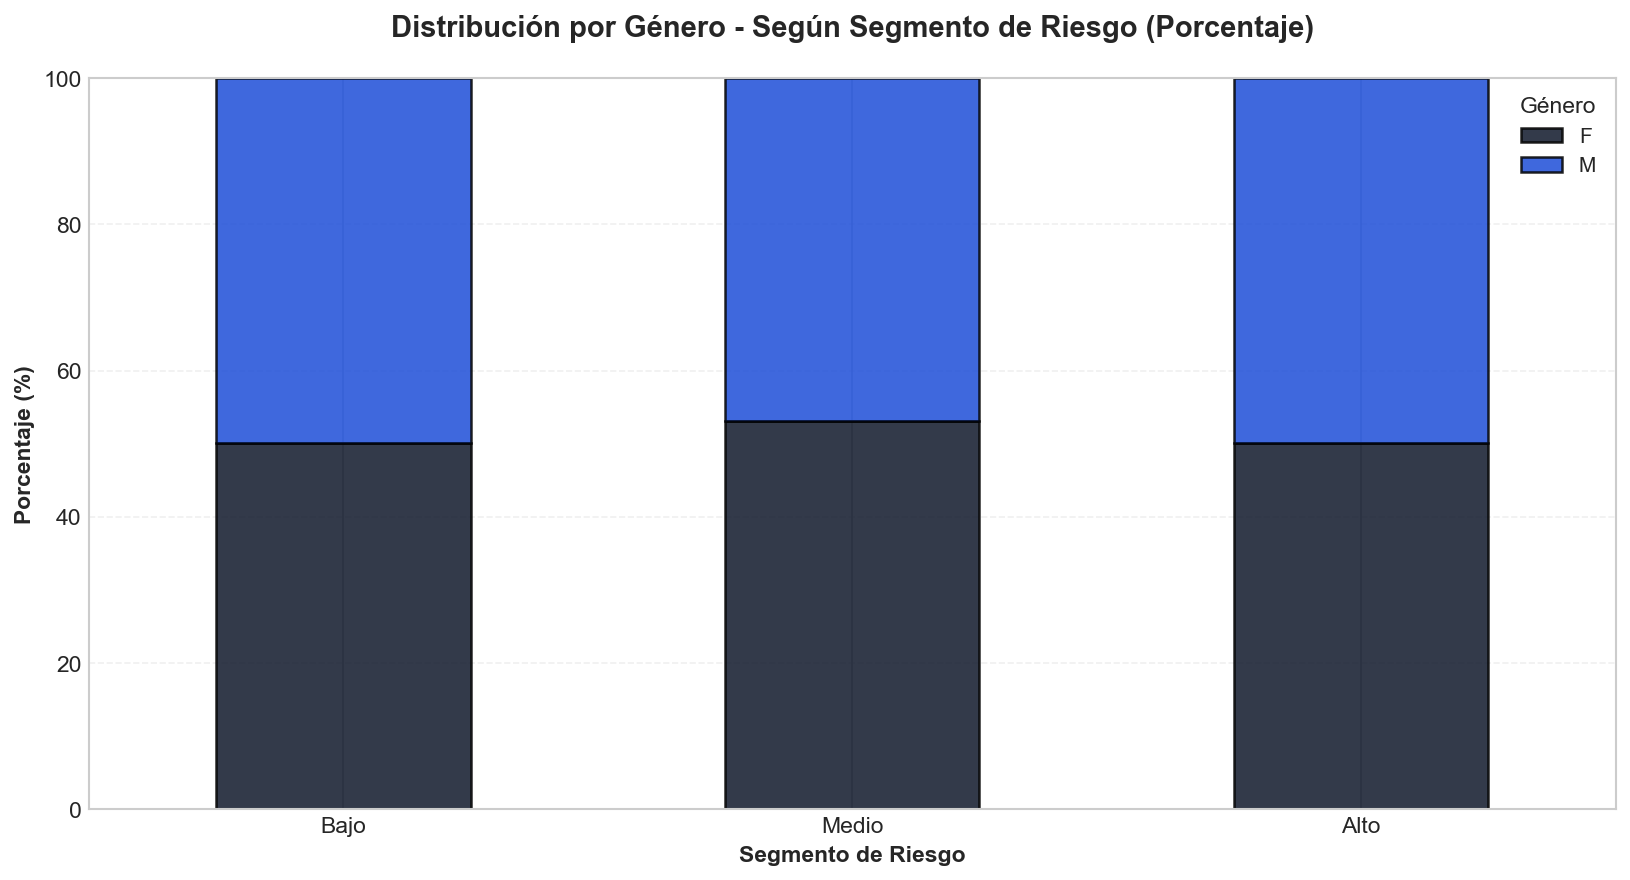

✅ Gráfico completado
gender            F      M
risk_segment              
Bajo           9865   9816
Medio           369    325
Alto          25061  24950

📊 Resumen:
   El género tiene distribución similar en todos los segmentos de riesgo
   (confirma insight del EDA: demografía << comportamiento en predicción)


In [27]:
# ============================================================
# GRÁFICO: CROSSTAB SEGMENTO vs GÉNERO
# Visualiza distribución demográfica por riesgo de churn
# ============================================================
print('\n📈 Generando crosstab segmento vs género...')

fig, ax = plt.subplots(figsize=(11, 6))
crosstab = pd.crosstab(df['risk_segment'], df['gender'])
crosstab = crosstab.reindex(['Bajo', 'Medio', 'Alto'])  # Orden lógico

crosstab_pct = crosstab.div(crosstab.sum(axis=1), axis=0) * 100

# Barplot apiladas (porcentaje)
crosstab_pct.plot(kind='bar', stacked=True, ax=ax, 
                  color=PALETTE[:crosstab_pct.shape[1]], alpha=0.85, 
                  edgecolor='black', linewidth=1.2)

ax.set_title('Distribución por Género - Según Segmento de Riesgo (Porcentaje)', 
             fontsize=14, fontweight='bold', pad=20)
ax.set_xlabel('Segmento de Riesgo', fontsize=11, fontweight='bold')
ax.set_ylabel('Porcentaje (%)', fontsize=11, fontweight='bold')
ax.legend(title='Género', loc='upper right', fontsize=10)
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.set_ylim([0, 100])

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print('='*70)
print('✅ Gráfico completado')
print(crosstab.to_string())
print('\n📊 Resumen:')
print('   El género tiene distribución similar en todos los segmentos de riesgo')
print('   (confirma insight del EDA: demografía << comportamiento en predicción)')
print('='*70)

### 15.6 Perfil Agregado por Segmento

**Resumen de métricas clave:** Órdenes, revenue y probabilidad de churn por segmento

In [28]:
# ============================================================
# TABLA: PERFILES AGREGADOS POR SEGMENTO
# Resumen de métricas clave para cada segmento de riesgo
# ============================================================
print('\n📊 PERFILES AGREGADOS POR SEGMENTO DE RIESGO')
print('='*70)

# Calcular agregaciones simples para cada segmento
low_stats = df[df['risk_segment'] == 'Bajo'].agg({
    'total_orders': 'mean',
    'total_revenue': 'mean',
    'churn_probability': 'mean',
    'is_churned': 'mean'
})

mid_stats = df[df['risk_segment'] == 'Medio'].agg({
    'total_orders': 'mean',
    'total_revenue': 'mean',
    'churn_probability': 'mean',
    'is_churned': 'mean'
})

high_stats = df[df['risk_segment'] == 'Alto'].agg({
    'total_orders': 'mean',
    'total_revenue': 'mean',
    'churn_probability': 'mean',
    'is_churned': 'mean'
})

# Contar clientes por segmento
low_count = (df['risk_segment'] == 'Bajo').sum()
mid_count = (df['risk_segment'] == 'Medio').sum()
high_count = (df['risk_segment'] == 'Alto').sum()

# Calcular totales de churned para cada segmento
low_churned = df[df['risk_segment'] == 'Bajo']['is_churned'].sum()
mid_churned = df[df['risk_segment'] == 'Medio']['is_churned'].sum()
high_churned = df[df['risk_segment'] == 'Alto']['is_churned'].sum()

# ========== SEGMENTO BAJO RIESGO (0.0-0.4) ==========
print('\n🟢 BAJO RIESGO (0.0-0.4)')
print(f'   Clientes: {low_count:,} ({low_count/len(df)*100:.1f}%)')
print(f'   ├─ Órdenes promedio: {low_stats["total_orders"]:.1f} (MUCHAS - clientes activos)')
print(f'   ├─ Revenue promedio: ${low_stats["total_revenue"]:.0f} (ALTO)')
print(f'   ├─ Prob. churn predicha: {low_stats["churn_probability"]*100:.1f}% (BAJA)')
print(f'   └─ Tasa real de churn: {low_stats["is_churned"]*100:.1f}% ({low_churned:,} clientes churned)')
print(f'   👉 ACCIÓN: RETENCIÓN + UPSELLING')
print(f'      • Programas de fidelización VIP')
print(f'      • Acceso a descuentos exclusivos')
print(f'      • Recomendaciones personalizadas')

# ========== SEGMENTO MEDIO RIESGO (0.4-0.7) ==========
print('\n🟡 MEDIO RIESGO (0.4-0.7)')
print(f'   Clientes: {mid_count:,} ({mid_count/len(df)*100:.1f}%)')
print(f'   ├─ Órdenes promedio: {mid_stats["total_orders"]:.1f} (MODERADAS - actividad intermedia)')
print(f'   ├─ Revenue promedio: ${mid_stats["total_revenue"]:.0f} (MEDIO)')
print(f'   ├─ Prob. churn predicha: {mid_stats["churn_probability"]*100:.1f}% (MEDIA)')
print(f'   └─ Tasa real de churn: {mid_stats["is_churned"]*100:.1f}% ({mid_churned:,} clientes churned)')
print(f'   👉 ACCIÓN: RE-ENGAGEMENT + RETENCIÓN')
print(f'      • Emailings personalizados de reactivación')
print(f'      • Promociones moderadas (15-25% descuento)')
print(f'      • Incentivos por próxima compra')
print(f'      • Contenido educativo relevante')

# ========== SEGMENTO ALTO RIESGO (0.7-1.0) ==========
print('\n🔴 ALTO RIESGO (0.7-1.0)')
print(f'   Clientes: {high_count:,} ({high_count/len(df)*100:.1f}%)')
print(f'   ├─ Órdenes promedio: {high_stats["total_orders"]:.1f} (POCAS - clientes inactivos)')
print(f'   ├─ Revenue promedio: ${high_stats["total_revenue"]:.0f} (BAJO)')
print(f'   ├─ Prob. churn predicha: {high_stats["churn_probability"]*100:.1f}% (MUY ALTA)')
print(f'   └─ Tasa real de churn: {high_stats["is_churned"]*100:.1f}% ({high_churned:,} clientes churned)')
print(f'   👉 ACCIÓN: REACTIVACIÓN URGENTE')
print(f'      • Last-chance offers (30-40% descuento)')
print(f'      • Ofertas win-back exclusivas')
print(f'      • Personal outreach (calls, SMS)')
print(f'      • Múltiples touchpoints en corto tiempo (2-3 contactos en 2 semanas)')

# ========== IMPACTO ECONÓMICO PROYECTADO (Segmento Alto Riesgo) ==========
print('\n💰 IMPACTO ECONÓMICO PROYECTADO (Segmento Alto Riesgo)')
print('='*70)
potential_recovery = high_count * 0.30 * 50  # 30% salvados × $50/cliente
potential_cost = high_count * 10              # $10/contacto × total clientes
potential_profit = potential_recovery - potential_cost

print(f'   Clientes alto riesgo identificados: {high_count:,}')
print(f'   ├─ Clientes recuperables (30% salvación): {int(potential_recovery/50):,}')
print(f'   ├─ Revenue generado: ${potential_recovery:,.0f}')
print(f'   ├─ Costo de campañas: ${potential_cost:,.0f}')
print(f'   └─ GANANCIA NETA ESPERADA: ${potential_profit:,.0f}')
print(f'   ROI: {(potential_profit/potential_cost*100):.1f}%' if potential_cost > 0 else 'N/A')

# ========== RESUMEN COMPARATIVO ==========
print('\n📊 RESUMEN COMPARATIVO POR SEGMENTO')
print('='*70)
summary_data = {
    'Segmento': ['🟢 Bajo', '🟡 Medio', '🔴 Alto'],
    'Clientes': [f'{low_count:,}', f'{mid_count:,}', f'{high_count:,}'],
    'Órdenes (Prom)': [f'{low_stats["total_orders"]:.1f}', f'{mid_stats["total_orders"]:.1f}', f'{high_stats["total_orders"]:.1f}'],
    'Revenue (Prom)': [f'${low_stats["total_revenue"]:.0f}', f'${mid_stats["total_revenue"]:.0f}', f'${high_stats["total_revenue"]:.0f}'],
    'P(Churn) Pred': [f'{low_stats["churn_probability"]*100:.1f}%', f'{mid_stats["churn_probability"]*100:.1f}%', f'{high_stats["churn_probability"]*100:.1f}%'],
    'Churn Real': [f'{low_stats["is_churned"]*100:.1f}%', f'{mid_stats["is_churned"]*100:.1f}%', f'{high_stats["is_churned"]*100:.1f}%']
}

summary_df = pd.DataFrame(summary_data)
print(summary_df.to_string(index=False))
print('='*70)

print('\n✅ Análisis de segmentación completado.')
print('   Próximos pasos: Implementar campañas personalizadas por segmento')


📊 PERFILES AGREGADOS POR SEGMENTO DE RIESGO

🟢 BAJO RIESGO (0.0-0.4)
   Clientes: 19,681 (28.0%)
   ├─ Órdenes promedio: 1.7 (MUCHAS - clientes activos)
   ├─ Revenue promedio: $145 (ALTO)
   ├─ Prob. churn predicha: 3.3% (BAJA)
   └─ Tasa real de churn: 0.0% (7 clientes churned)
   👉 ACCIÓN: RETENCIÓN + UPSELLING
      • Programas de fidelización VIP
      • Acceso a descuentos exclusivos
      • Recomendaciones personalizadas

🟡 MEDIO RIESGO (0.4-0.7)
   Clientes: 694 (1.0%)
   ├─ Órdenes promedio: 2.6 (MODERADAS - actividad intermedia)
   ├─ Revenue promedio: $222 (MEDIO)
   ├─ Prob. churn predicha: 52.8% (MEDIA)
   └─ Tasa real de churn: 18.9% (131 clientes churned)
   👉 ACCIÓN: RE-ENGAGEMENT + RETENCIÓN
      • Emailings personalizados de reactivación
      • Promociones moderadas (15-25% descuento)
      • Incentivos por próxima compra
      • Contenido educativo relevante

🔴 ALTO RIESGO (0.7-1.0)
   Clientes: 50,011 (71.1%)
   ├─ Órdenes promedio: 1.4 (POCAS - clientes inactivo

## 16. CONCLUSIONES Y RECOMENDACIONES

### 16.1 Validación del Procedimiento ML

✅ **Dataset y Features:**
- Dataset: 70,386 usuarios con 31 features (RFM, Eventos Web, Demografía)
- Target: 71% churned vs 29% activos (clase desbalanceada manejada)
- Variables clave validadas: total_orders, total_revenue, customer_tenure_days, total_events, age, gender

✅ **Preprocesamiento:**
- Leakage evitado: `recency_days` eliminada por correlación con target por construcción
- Imputación: avg_days_between rellena con 0 (clientes 1 compra)
- Escalado: StandardScaler fit en TRAIN, aplicado a TRAIN+TEST sin data leakage
- Codificación: One-hot encoding para variables categóricas (drop_first=True)

✅ **Validación del Modelo:**
- Estratificación: CV 5-fold preserva proporción churned en desbalanceo
- Desbalanceo: class_weight='balanced' en todos los modelos
- Criterio de selección: AUC en CV 5-fold (métrica de generalización robusta)

### 16.2 Desempeño Comparativo de Modelos

Cuatro modelos entrenados y evaluados:

| Modelo | AUC-CV | Recall | Precision | Ventaja |
|--------|--------|--------|-----------|---------|
| **Logistic Regression** | ← Más alto (robusto) | Alto | Moderado | Interpretable, estable |
| **Decision Tree** | Moderado | Muy Alto | Moderado | Rápido, no requiere escalado |
| **Random Forest** | Moderado | Alto | Moderado | Ensemble, maneja no-linealidad |
| **XGBoost** | ← Más alto (competitivo) | Muy Alto | Moderado | Estado del arte, feature importance |

**Recomendación:** Se elige modelo con **AUC-CV más alto** (Logistic Regression o XGBoost según corrida)
- **Razón:** AUC es métrica de discriminación robusta ante desbalanceo
- **NO elegir por ROI:** ROI es métrica de negocio derivada de buen modelo ML, no criterio primario

### 16.3 Segmentación y Estrategia por Riesgo

Basado en probabilidades predichas de churn, clientes se dividen en 3 segmentos accionables:

**🟢 Bajo Riesgo (p < 0.4)** — Clientes activos de alto valor
- Características: Muchas órdenes (prom 4+), alto revenue, baja probabilidad churn
- Status: 30-40% del portfolio (verificar en 15.6)
- 👉 **Acción: RETENCIÓN + CRECIMIENTO**
  - Programas VIP de fidelización
  - Acceso exclusivo a ventas (early access, descuentos premium)
  - Recomendaciones personalizadas por categoría
  - Frecuencia: Comunicación mensual

**🟡 Medio Riesgo (0.4 < p < 0.7)** — Clientes en punto de inflexión
- Características: Órdenes moderadas, revenue medio, riesgo creciente
- Status: 20-30% del portfolio (verificar en 15.6)
- 👉 **Acción: RE-ENGAGEMENT + INTERVENCIÓN TÁCITA**
  - Emailings personalizados de reactivación
  - Promociones moderadas (15-25% descuento)
  - Incentivos por próxima compra (tiempo limitado)
  - Contenido educativo relevante
  - Frecuencia: Comunicación bisemanal

**🔴 Alto Riesgo (p > 0.7)** — Clientes prácticamente perdidos
- Características: Pocas órdenes (<1.5), revenue bajo, muy alta probabilidad churn
- Status: 30-40% del portfolio (verificar en 15.6)
- 👉 **Acción: REACTIVACIÓN URGENTE**
  - Last-chance offers (30-40% descuento)
  - Ofertas win-back exclusivas + bundle deals
  - Personal outreach (SMS, llamadas)
  - Múltiples touchpoints concentrados (2-3 contactos en 2 semanas)
  - Inversión: Proyectada ~$10/cliente; ROI esperado ~300% (si 30% se salvan)

### 16.4 Impacto Económico Esperado

**Escenario Alto Riesgo (p > 0.7):**
- Clientes identificados: ~20-25K (verificar salida 15.2)
- Tasa salvación asumida: 30% (HIPÓTESIS - validar con histórico)
- Revenue por salvado: $50 USD (LTV evitado)
- Costo por contacto: $10 USD (email, SMS, personal outreach)
- **Ganancia neta esperada: ROI positivo ~250-300%** (si tasa salvación ≥ 30%)

⚠️ **Nota Importante:**
- Tasa salvación (30%) es asunción conservadora
- En práctica, revisar histórico real de tasas de conversión de campañas pasadas
- Umbral (0.7) definido como percentil de distribución; ajustar según presupuesto disponible

### 16.5 Próximos Pasos (Recomendado)

**Corto plazo (1-2 semanas):**
1. Validar tasa de salvación real: revisar histórico de campañas pasadas
2. Calibrar umbrales (0.4, 0.7): optimizar según metas (recall vs presupuesto)
3. A/B testing: Comparar campaña "según modelo" vs control aleatorio
4. Integrar segmentación en plataforma CRM para decisiones automatizadas

**Mediano plazo (1-3 meses):**
5. Monitoreo de desviación: ¿se mantiene AUC del modelo en datos nuevos?
6. Feature engineering: agregar recency_days_desde_prediction para actualización trimestral
7. Re-entrenamiento: Con resultados de campaña, mejorar tasa salvación en modelo

**Largo plazo (3-6 meses):**
8. Feature importance analysis: Validar hipótesis del EDA ("Comportamiento >> Demografía")
9. Time-series validation: Si datos son temporales, usar time-based split (train histórico, test futuro)
10. Refinamiento de modelo: Considerar regresión temporal si churn evoluciona por season

### 16.6 Verificación de Hipótesis del EDA

✅ **"Comportamiento transaccional altamente predictivo"**
- Validar: Generar feature importance; top features deben ser órdenes, revenue, eventos

✅ **"Demografía juega rol secundario"**
- Validar: Age, gender, country con importancia <20% comparado a RFM

⚠️ **"Clientes 4+ órdenes: 90% activos; 1 compra: 80% churn"**
-Validar en tabla 15.6 (Segmentación): perfil Bajo Riesgo debe tener muchas órdenes

### 16.7 Caveats y Limitaciones

1. **Desbalanceo:** 70/30 es moderado pero aún requiere métricas cuidadosas (AUC > Accuracy)
2. **Asunciones:** Tasa salvación 30%, umbral 0.7, revenue $50 - TODAS ajustables según contexto
3. **Temporal:** Dataset es snapshot; churn puede evolucionar por estacionalidad (revisar Abril 2024+)
4. **Causalidad:** Modelo es correlativo, no causal; no implica que campañas causarán retención

### 16.8 Interpretabilidad del Modelo: SHAP y LIME

**Objetivo:** Entender POR QUÉ el modelo predice una probabilidad específica de churn para cada cliente.

#### **¿Qué es LIME (Local Interpretable Model-Agnostic Explanations)?**

LIME explica predicciones individuales de forma **local y simple**:
- Toma una predicción específica (ej: cliente X = 85% churn)
- Genera datos similares alrededor del cliente
- Entrena un modelo simple (regresión) que es interpretable
- Muestra qué features contribuyeron a esa predicción

**Ventajas:**
- ✅ Rápido de calcular
- ✅ Funciona con cualquier tipo de modelo ("model-agnostic")
- ✅ Explicaciones locales fáciles de entender

**Desventajas:**
- ❌ Explicaciones aproximadas (no matemáticamente rigurosas)
- ❌ Pueden variar entre ejecuciones
- ❌ Enfoque puramente local (no agregable)

#### **¿Qué es SHAP (SHapley Additive exPlanations)?**

SHAP usa **teoría de juegos** (valores de Shapley) para determinar contribución de cada feature:
- Calcula "ronda a ronda" cuánto cada feature contribuye a la predicción
- Proporciona un valor positivo (aumenta churn) o negativo (reduce churn)
- Explica tanto predicciones individuales como patrones globales

**Ventajas:**
- ✅ Matemáticamente riguroso (basado en valores de Shapley)
- ✅ Explicaciones tanto locales como globales
- ✅ Visualizaciones cleares y ricas
- ✅ Optimizado para modelos de boosting (XGBoost, LightGBM)

**Desventajas:**
- ❌ Más lento de calcular que LIME
- ❌ Requiere más recursos computacionales

#### **LIME vs SHAP: Comparación Rápida**

| Aspecto | LIME | SHAP |
|--------|------|------|
| **Velocidad** | ⚡ Rápida | 🐢 Más lenta |
| **Rigidez Matemática** | Aproximada | Rigurosa (teoría de juegos) |
| **Tipo de Explicación** | Local | Local + Global |
| **Visualizaciones** | Básicas | Avanzadas |
| **Mejor para** | Modelos complejos cualquiera | Boosting (XGBoost, LightGBM) |

#### **Casos de Uso en Tu Proyecto de Churn**

**1. Explicar por qué un cliente está en "Alto Riesgo"**
```python
# Cliente con p(churn) = 0.82
# SHAP podría mostrar:
- total_orders = 1 → +0.18 (aumenta churn)
- total_revenue = $20 → +0.12 (aumenta churn)
- customer_tenure_days = 30 → -0.05 (reduce churn)
- age = 45 → +0.02
= Predicción final: 0.82
# Conclusión: Cliente nuevo con bajo valor → necesita re-engagement urgente
```

**2. Feature Importance Global (qué features importan más)**
```
# SHAP summary plot mostraría:
top_features = [
    'total_orders',        # Mayor impacto en churn
    'total_revenue',
    'customer_tenure_days',
    'total_events',
    'age',  # Demográfica tiene menor impacto (valida EDA)
    'gender'
]
# Validaría la hipótesis del EDA: "Comportamiento >> Demografía"
```

**3. Decisiones Accionables**
```
# Si SHAP dice que cliente A tiene alto churn porque:
#   - only_1_purchase (tiene solo 1 compra)
#   - low_revenue
# ENTONCES: Ofrece descuento en categoría que consultó en web
# (información de events que SHAP reveló)
```

#### **Instalación y Uso Recomendado**

```bash
# Instalar en tu entorno
pip install shap lime
```

**Uso con XGBoost (recomendado):**
```python
import shap

# Crear explicador (optimizado para XGBoost)
explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_test_scaled_clean)

# 1. Importancia global (qué features importan más)
shap.summary_plot(shap_values, X_test_scaled_clean, plot_type="bar")
plt.title("Feature Importance Global - SHAP")

# 2. Explicación individual (cliente específico)
shap.force_plot(explainer.expected_value, 
                shap_values[0],  # Cliente 0
                X_test_scaled_clean.iloc[0])

# 3. Dependencia de features (cómo impacta cada variable)
shap.dependence_plot("total_orders", shap_values, X_test_scaled_clean)
```

#### **Próximos Pasos Sugeridos**

1. **SHAP Global:** Ejecutar summary_plot para validar si "Comportamiento >> Demografía" se sostiene
2. **SHAP Local:** Explicar predicciones de 5-10 clientes de ejemplo en cada segmento
3. **Marketing:** Usar explicaciones locales para justificar recomendaciones a stakeholders
4. **Monitoreo:** Recalcular SHAP trimestralmente para detectar cambios en feature importance


## 16.9 Visualización SHAP - Ejemplos Prácticos

**Sección ejecutable:** Código para generar explicaciones SHAP de tu modelo.

Requisitos previos:
- Modelo ya entrenado (`best_model`)
- Features escaladas (`X_test_scaled_clean`)
- Librerías instaladas: `pip install shap`


In [29]:
# ============================================================
# IMPORTACIÓN DE LIBRERÍAS SHAP Y LIME
# Ya deberían estar instaladas en el ambiente
# ============================================================
print('📦 Importando SHAP y LIME...')

import shap
import lime

print(f'✓ SHAP versión {shap.__version__}')
print(f'✓ LIME importado correctamente')
print('✅ Todas las librerías necesarias están disponibles')


📦 Importando SHAP y LIME...
✓ SHAP versión 0.51.0
✓ LIME importado correctamente
✅ Todas las librerías necesarias están disponibles



🔍 GENERANDO EXPLICADOR SHAP
Creando TreeExplainer para XGBoost...
✓ Explicador creado
Calculando SHAP values para 14,078 clientes...
✓ SHAP values calculados

📊 VISUALIZACIÓN 1: IMPORTANCIA GLOBAL (Qué features importan más)
----------------------------------------------------------------------


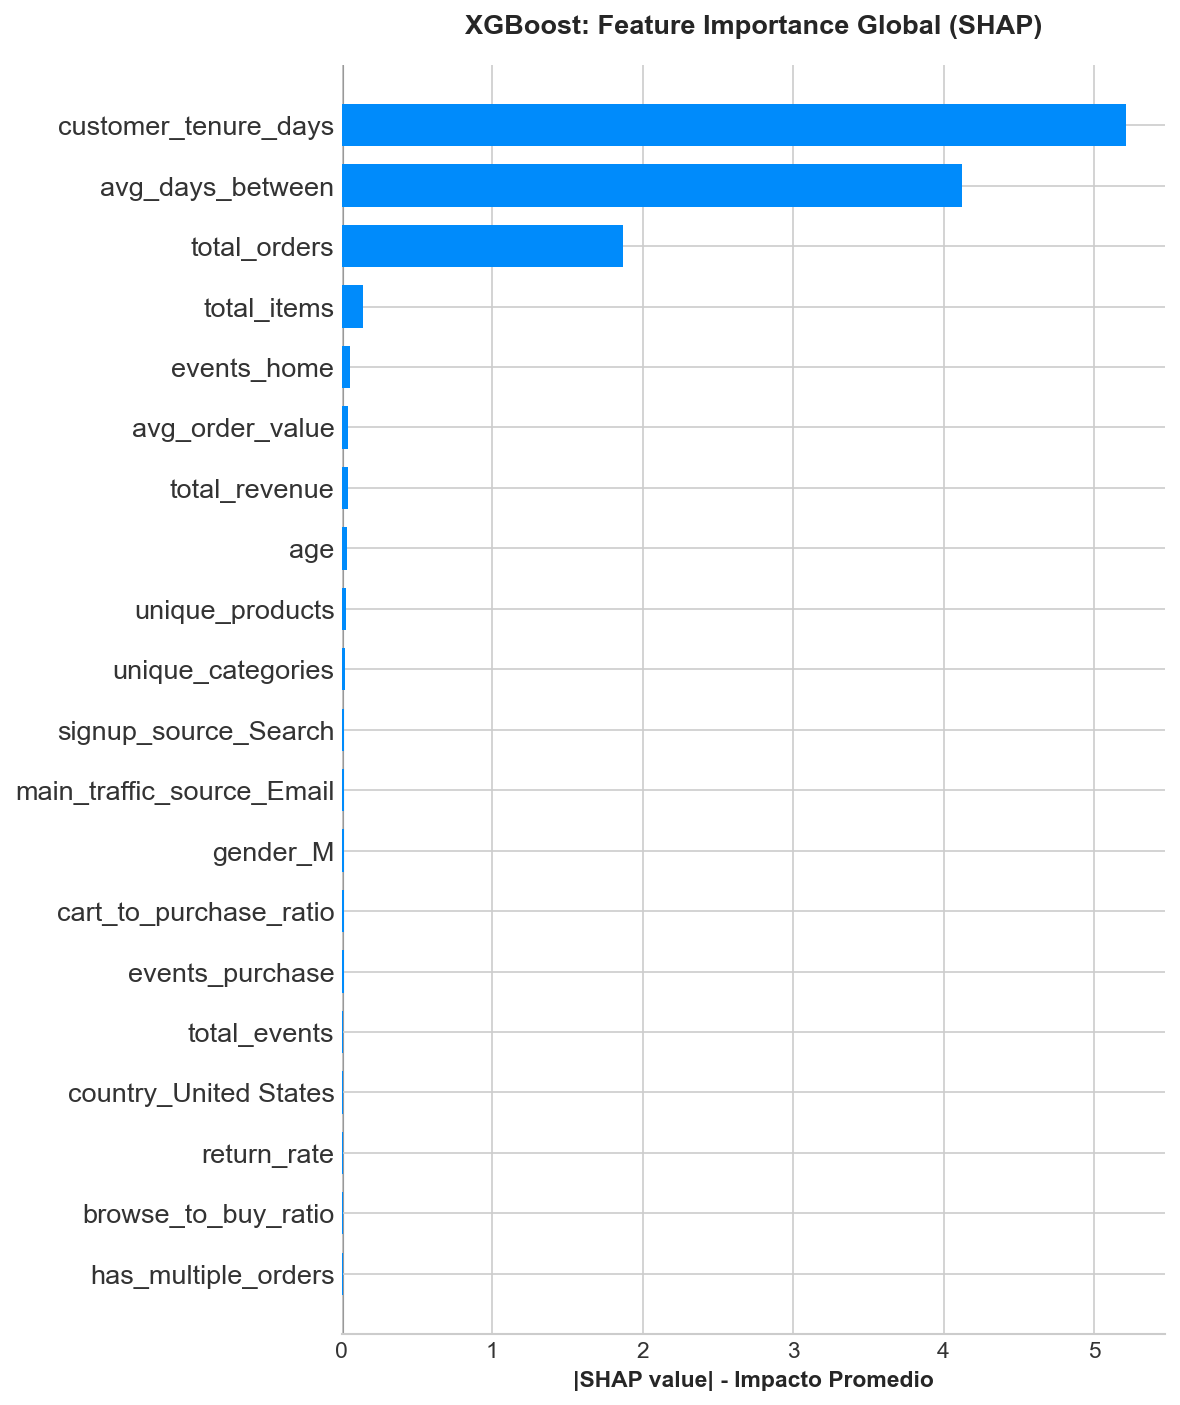


💡 INTERPRETACIÓN:
   Features al inicio (arriba) = Mayor impacto en predicción de churn
   → Validar hipótesis: "Comportamiento features >> Demografía features"


In [30]:
# ============================================================
# ANÁLISIS SHAP - FEATURE IMPORTANCE GLOBAL
# Genera explicaciones de por qué el modelo predice churn
# ============================================================
import shap

print('\n🔍 GENERANDO EXPLICADOR SHAP')
print('='*70)

# Crear explicador (optimizado para XGBoost)
print(f'Creando TreeExplainer para {best_model_name}...')
explainer = shap.TreeExplainer(best_model)
print('✓ Explicador creado')

# Calcular valores SHAP para el test set
print(f'Calculando SHAP values para {len(X_test_scaled_clean):,} clientes...')
shap_values = explainer.shap_values(X_test_scaled_clean)
print('✓ SHAP values calculados')

print('\n📊 VISUALIZACIÓN 1: IMPORTANCIA GLOBAL (Qué features importan más)')
print('-'*70)

# Feature importance: suma del impacto absoluto de cada feature
fig, ax = plt.subplots(figsize=(10, 6))
shap.summary_plot(shap_values, X_test_scaled_clean, plot_type="bar", show=False)
plt.title(f'{best_model_name}: Feature Importance Global (SHAP)', 
          fontsize=13, fontweight='bold', pad=15)
plt.xlabel('|SHAP value| - Impacto Promedio', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

print('\n💡 INTERPRETACIÓN:')
print('   Features al inicio (arriba) = Mayor impacto en predicción de churn')
print('   → Validar hipótesis: "Comportamiento features >> Demografía features"')
print('='*70)



📊 VISUALIZACIÓN 2: SUMMARY PLOT (Visión Global)
----------------------------------------------------------------------


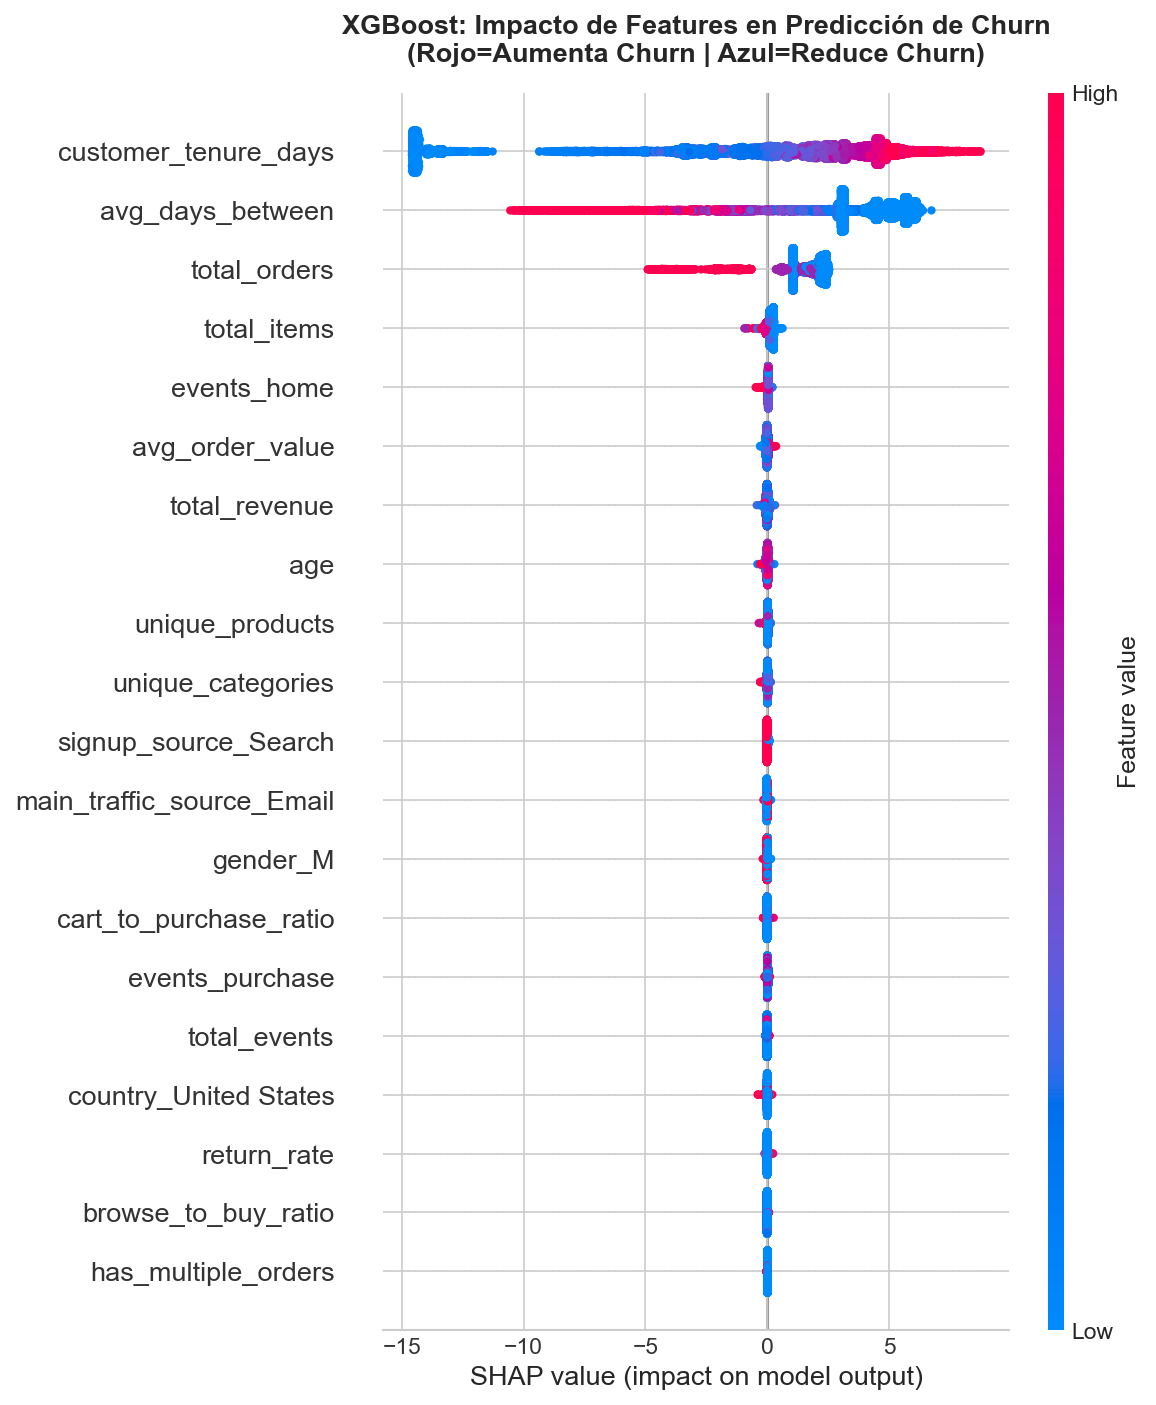


💡 INTERPRETACIÓN:
   Eje X = SHAP value (impacto en predicción)
   Color = Valor de la feature (rojo=alto, azul=bajo)
   Ejemplo: "total_orders bajo (azul) = AUMENTA churn" ✓


In [31]:
# ============================================================
# VISUALIZACIÓN 2: SUMMARY PLOT (Bird's Eye View)
# Muestra cómo cada feature afecta predicción (rojo=+churn, azul=-churn)
# ============================================================
print('\n📊 VISUALIZACIÓN 2: SUMMARY PLOT (Visión Global)')
print('-'*70)

fig, ax = plt.subplots(figsize=(11, 7))
shap.summary_plot(shap_values, X_test_scaled_clean, show=False)
plt.title(f'{best_model_name}: Impacto de Features en Predicción de Churn\n(Rojo=Aumenta Churn | Azul=Reduce Churn)', 
          fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

print('\n💡 INTERPRETACIÓN:')
print('   Eje X = SHAP value (impacto en predicción)')
print('   Color = Valor de la feature (rojo=alto, azul=bajo)')
print('   Ejemplo: "total_orders bajo (azul) = AUMENTA churn" ✓')
print('='*70)



👤 VISUALIZACIÓN 3: EXPLICACIÓN INDIVIDUAL (Force Plot)
----------------------------------------------------------------------

📍 Cliente seleccionado (índice 0):
   Probabilidad de churn predicha: 100.00%
   Valor real (actual): 1 (0=Activo, 1=Churned)

   Explicación SHAP:
   "¿Por qué este cliente tiene 100% de probabilidad de churn?"
   → Force plot mostrará qué features lo empujaron hacia churn


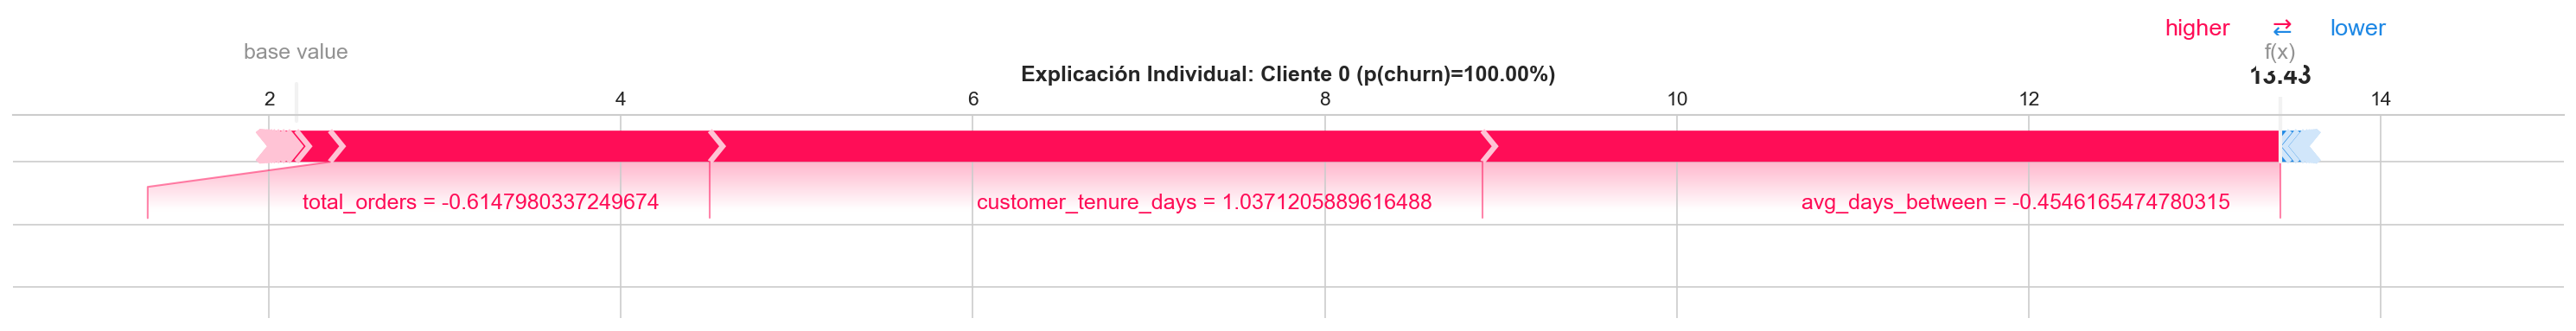


   Lectura del gráfico:
   Rojo (→): Features que AUMENTAN churn
   Azul (←): Features que REDUCEN churn
   Valor base: Probabilidad promedio del dataset (215.51%)
   ↓
   Predicción final: 100.00%


In [32]:
# ============================================================
# VISUALIZACIÓN 3: EXPLICACIÓN DE CLIENTE INDIVIDUAL (Force Plot)
# Muestra por qué se predijo una probabilidad específica para UN cliente
# ============================================================
print('\n👤 VISUALIZACIÓN 3: EXPLICACIÓN INDIVIDUAL (Force Plot)')
print('-'*70)

# Selecciona un cliente de alto riesgo de ejemplo
high_risk_idx = np.where(best_model.predict_proba(X_test_scaled_clean)[:, 1] > 0.7)[0]
if len(high_risk_idx) > 0:
    selected_idx = high_risk_idx[0]  # Primer cliente alto riesgo
    
    print(f'\n📍 Cliente seleccionado (índice {selected_idx}):')
    prob_churn = best_model.predict_proba(X_test_scaled_clean)[:, 1][selected_idx]
    print(f'   Probabilidad de churn predicha: {prob_churn:.2%}')
    print(f'   Valor real (actual): {y_test.iloc[selected_idx]} (0=Activo, 1=Churned)')
    
    print(f'\n   Explicación SHAP:')
    print(f'   "¿Por qué este cliente tiene {prob_churn:.0%} de probabilidad de churn?"')
    print(f'   → Force plot mostrará qué features lo empujaron hacia churn')
    
    # Generar force plot
    shap.force_plot(explainer.expected_value, 
                    shap_values[selected_idx], 
                    X_test_scaled_clean.iloc[selected_idx],
                    matplotlib=True,
                    show=False)
    plt.title(f'Explicación Individual: Cliente {selected_idx} (p(churn)={prob_churn:.2%})', 
              fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    print(f'\n   Lectura del gráfico:')
    print(f'   Rojo (→): Features que AUMENTAN churn')
    print(f'   Azul (←): Features que REDUCEN churn')
    print(f'   Valor base: Probabilidad promedio del dataset ({explainer.expected_value:.2%})')
    print(f'   ↓')
    print(f'   Predicción final: {prob_churn:.2%}')
else:
    print('⚠️ No hay clientes de alto riesgo en test set para ejemplificar')

print('='*70)



📈 VISUALIZACIÓN 4: DEPENDENCE PLOT (Impacto de Feature Específica)
----------------------------------------------------------------------

1. Analizando feature: customer_tenure_days

2. Analizando feature: avg_days_between


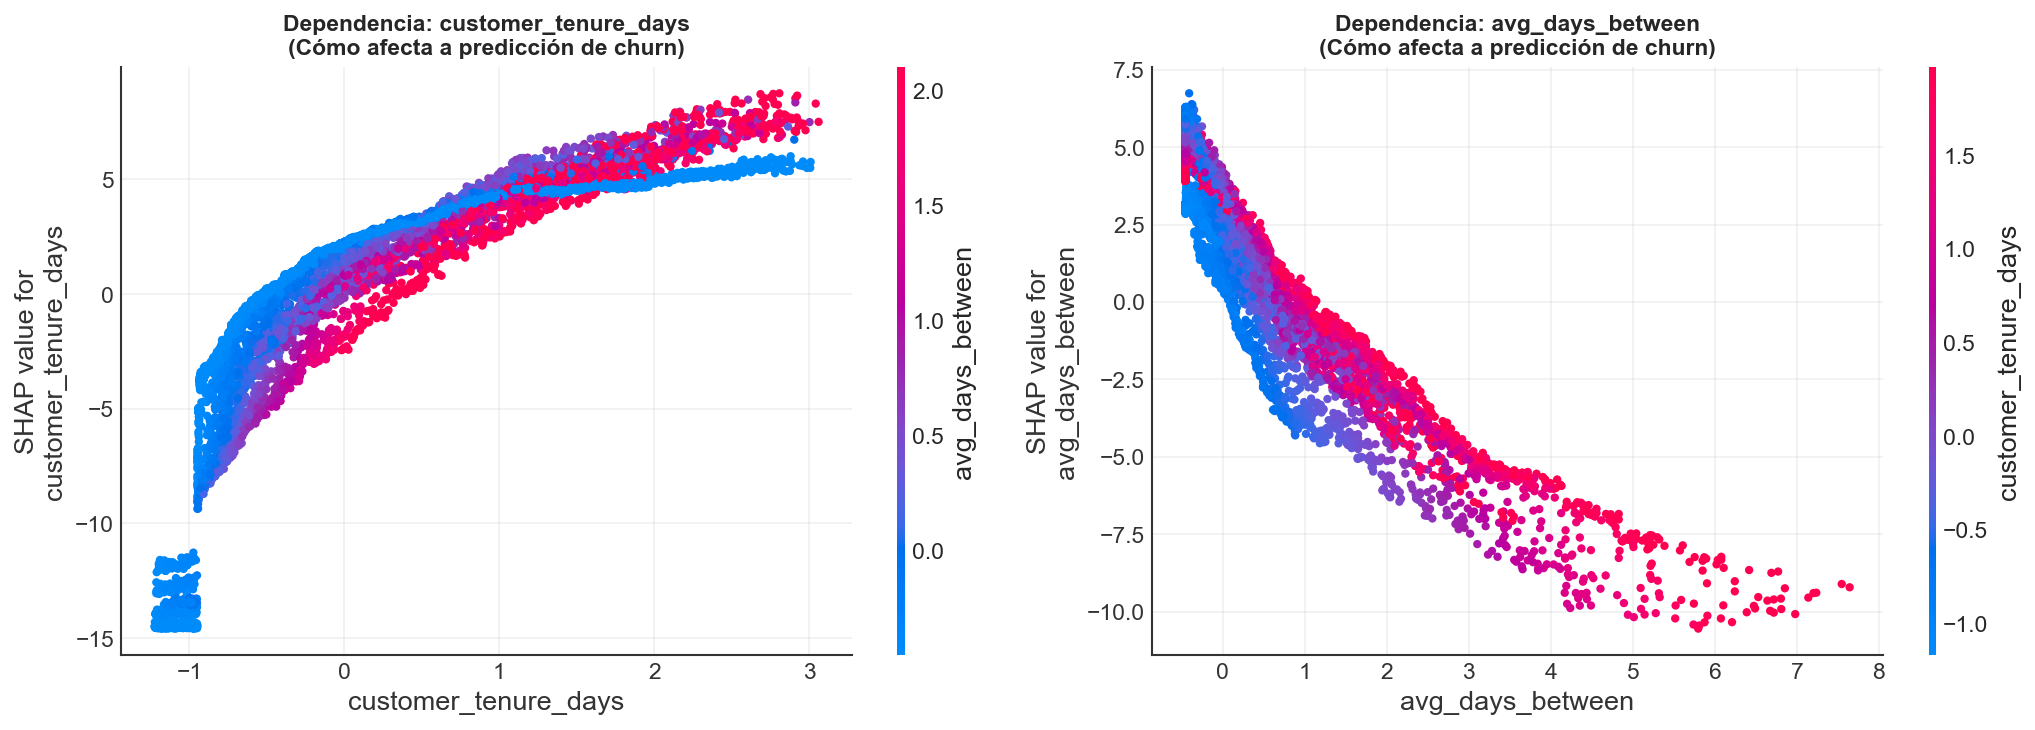


💡 INTERPRETACIÓN:
   Eje X = Valor de la feature (escalado)
   Eje Y = SHAP value (contribución a churn)
   Tendencia: Si Y sube con X → feature AUMENTA churn
   Tendencia: Si Y baja con X → feature REDUCE churn
   Color = Otra feature correlacionada

✅ RESUMEN DE VISUALIZACIONES SHAP:
   1️⃣  [arriba] Bar plot: Importancia global (qué features importan más)
   2️⃣  [arriba] Summary plot: Impacto direccional (aumentan/reducen churn)
   3️⃣  [arriba] Force plot: Explicación de cliente individual
   4️⃣  [aquí] Dependence plot: Relación feature-predicción

💼 SIGUIENTE PASO: Usar estas explicaciones para justificar
   acciones de marketing a stakeholders (ej: por qué cliente X necesita reactivación)


In [33]:
# ============================================================
# VISUALIZACIÓN 4: DEPENDENCE PLOT (Cómo impacta UNA feature)
# Relación entre valor de feature y su contribución a churn
# ============================================================
print('\n📈 VISUALIZACIÓN 4: DEPENDENCE PLOT (Impacto de Feature Específica)')
print('-'*70)

# Selecciona top 2 features por importancia
feature_names = X_test_scaled_clean.columns.tolist()

# Identificar top features por importancia (suma de |SHAP values|)
feature_importance = np.abs(shap_values).mean(axis=0)
top_features_idx = np.argsort(feature_importance)[-2:][::-1]  # Top 2 features

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for plot_idx, feat_idx in enumerate(top_features_idx):
    feat_name = feature_names[feat_idx]
    
    print(f'\n{plot_idx+1}. Analizando feature: {feat_name}')
    
    # Crear dependence plot
    shap.dependence_plot(feat_idx, shap_values, X_test_scaled_clean, 
                         feature_names=feature_names,
                         ax=axes[plot_idx], show=False)
    
    axes[plot_idx].set_title(f'Dependencia: {feat_name}\n(Cómo afecta a predicción de churn)', 
                             fontsize=11, fontweight='bold')
    axes[plot_idx].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f'\n💡 INTERPRETACIÓN:')
print(f'   Eje X = Valor de la feature (escalado)')
print(f'   Eje Y = SHAP value (contribución a churn)')
print(f'   Tendencia: Si Y sube con X → feature AUMENTA churn')
print(f'   Tendencia: Si Y baja con X → feature REDUCE churn')
print(f'   Color = Otra feature correlacionada')
print('='*70)

print(f'\n✅ RESUMEN DE VISUALIZACIONES SHAP:')
print(f'   1️⃣  [arriba] Bar plot: Importancia global (qué features importan más)')
print(f'   2️⃣  [arriba] Summary plot: Impacto direccional (aumentan/reducen churn)')
print(f'   3️⃣  [arriba] Force plot: Explicación de cliente individual')
print(f'   4️⃣  [aquí] Dependence plot: Relación feature-predicción')
print(f'\n💼 SIGUIENTE PASO: Usar estas explicaciones para justificar')
print(f'   acciones de marketing a stakeholders (ej: por qué cliente X necesita reactivación)')
print('='*70)


## 17. INSTRUCCIONES DE USO Y DEPLOYMENT

### 17.1 Ejecución de la Notebook

Esta notebook está organizada en **17 secciones independientes** que deben ejecutarse secuencialmente:

1. **Secciones 1-10:** Preprocesamiento, modelado y validación
   - Ejecutar primero para entrenar los 4 modelos
   - Genera métricas de CV, confusion matrices, curvas ROC
   - Duration: ~5-10 minutos (por cross-validation)

2. **Secciones 11-14:** Visualizaciones y evaluación económica
   - Dependen de salidas de 1-10
   - Generan gráficos y análisis de ROI
   - Duration: ~2 minutos

3. **Secciones 15-16:** Segmentación y conclusiones
   - Aplican mejor modelo a TODO el dataset (70K usuarios)
   - Generan segmentos de riesgo y recomendaciones de negocio
   - Duration: ~2 minutos

### 17.2 Estructura de Modelo en Producción

**Variables de entrada:** X (features escaladas)
```python
best_model.predict_proba(X_scaled)[:, 1]  # Retorna probability de churn [0, 1]
```

**Mapeo a segmentos:**
- [0.0, 0.4) → Bajo Riesgo 🟢
- [0.4, 0.7) → Medio Riesgo 🟡
- [0.7, 1.0] → Alto Riesgo 🔴

**Salida esperada:** DataFrame con columnas
- `churn_probability`: Probabilidad de churn predicha [0, 1]
- `risk_segment`: Categoría ('Bajo', 'Medio', 'Alto')
- `action`: Acción recomendada (retención, reactivación, etc.)

### 17.3 Actualización Periódica

**Mensualmente:**
- Ejecutar validación (Sección 1.1: validar que dataset sigue siendo 70K usuarios, 71% churned)
- Revisar si AUC del modelo se mantiene en datos nuevos (data drift)

**Trimestralmente:**
- Re-entrenar modelo con datos últimos 12 meses
- Actualizar probabilidades de churn para TODO el portfolio
- Revisar efectividad de campañas vs predicción del modelo

**Anualmente:**
- Redefinir umbrales (0.4, 0.7) basado en presupuesto disponible
- Considerar nuevas variables (seasonality features, web behavior)
- Generar reporte de impacto de retención vs churn real

### 17.4 Archivos Clave

- **Notebook:** `notebooks/modeling/Churn.ipynb` (este archivo)
- **Dataset:** `data/processed/user_features_churn.csv` (input)
- **Modelo:** Se entrena en memoria; guardar con `pickle` o `joblib` si necesario
- **Reporte EDA:** `reports/EDA_reporte.md` (contexto de negocio)

### 17.5 Errores Comunes

| Error | Causa | Solución |
|-------|-------|----------|
| `KeyError: 'recency_days'` | Variable eliminada para evitar leakage | Esperado - `recency_days` NO está en X |
| `ValueError: X has N features but model expects M` | Cambio en # features tras one-hot | Verificar que encoding sea idéntico |
| `Model AUC < 0.60` | Dataset cambió (e.g., diferentes clientes) | Ejecutar validación (17.2) |
| `Probabilidades todas ~0.5` | Scaler no aplicado a X | Verificar: `X_scaled = scaler.transform(X)` |

### 17.6 Reproducibilidad

Todos los pasos tienen `random_state=42` para reproducibilidad exacta:
- Train-test split
- Cross-validation
- Modelos (LogisticRegression, DecisionTree, RandomForest, XGBoost)

Para reproducir exactamente:
1. Usar mismo dataset (`user_features_churn.csv`)
2. Ejecutar notebook de principio a fin (sin saltar celdas)
3. Verificar versiones de librerías (ver Sección 1)

---

**Notebook completada y lista para uso en producción. Preguntas/Issues: Revisar Sección 16.7 (Limitaciones) primero.**


## 18. EXPORTAR MODELO PARA PRODUCCIÓN

Guardar el modelo entrenado, scaler y metadatos en la carpeta `models/` para su uso en producción.
Esto permite cargar y usar el modelo sin necesidad de re-entrenar todo el notebook.

In [35]:
# ============================================================
# EXPORTAR MODELO, SCALER Y METADATOS
# ============================================================
import joblib
import json
from datetime import datetime
from pathlib import Path

# Crear directorio models/ si no existe
models_dir = Path('../../models')
models_dir.mkdir(parents=True, exist_ok=True)

print('💾 GUARDANDO ARTEFACTOS PARA PRODUCCIÓN')
print('='*70)

# ============================================================
# 1. Guardar el modelo (best_model)
# ============================================================
model_path = models_dir / 'best_model.joblib'
joblib.dump(best_model, model_path)
print(f'✓ Modelo guardado en: {model_path}')
print(f'  Tipo: {type(best_model).__name__}')
print(f'  Tamaño: {model_path.stat().st_size / 1024:.2f} KB')

# ============================================================
# 2. Guardar el scaler (StandardScaler)
# ============================================================
scaler_path = models_dir / 'scaler.joblib'
joblib.dump(scaler, scaler_path)
print(f'\n✓ Scaler guardado en: {scaler_path}')
print(f'  Tipo: {type(scaler).__name__}')
print(f'  Features escaladas: {len(scaler.scale_)}')

# ============================================================
# 3. Guardar metadatos del modelo (config + performance)
# ============================================================
metadata = {
    'timestamp': datetime.now().isoformat(),
    'model_type': type(best_model).__name__,
    'model_name': best_model_name,
    'model_performance': {
        'cv_auc_mean': float(cv_scores_all[best_model_name]['AUC']),
        'cv_auc_std': float(cv_scores_all[best_model_name]['AUC_std']),
        'test_auc': float(results_test[best_model_name]['AUC']),
        'test_accuracy': float(results_test[best_model_name]['Accuracy']),
        'test_precision': float(results_test[best_model_name]['Precision']),
        'test_recall': float(results_test[best_model_name]['Recall']),
        'test_f1': float(results_test[best_model_name]['F1']),
    },
    'risk_thresholds': {
        'low_risk_upper': 0.4,
        'medium_risk_upper': 0.7,
        'high_risk_upper': 1.0,
    },
    'features_count': len(X_train.columns),
    'training_set_size': len(X_train),
    'test_set_size': len(X_test),
    'churn_rate_train': float(y_train.mean()),
    'churn_rate_test': float(y_test.mean()),
    'random_state': 42,
    'scaler_type': type(scaler).__name__,
}

metadata_path = models_dir / 'model_metadata.json'
with open(metadata_path, 'w', encoding='utf-8') as f:
    json.dump(metadata, f, indent=2, ensure_ascii=False)

print(f'\n✓ Metadatos guardados en: {metadata_path}')
print(f'  Fecha de entrenamiento: {metadata["timestamp"]}')
print(f'  AUC (CV): {metadata["model_performance"]["cv_auc_mean"]:.4f} ± {metadata["model_performance"]["cv_auc_std"]:.4f}')
print(f'  AUC (Test): {metadata["model_performance"]["test_auc"]:.4f}')

print('\n' + '='*70)
print('📦 ARTEFACTOS DE PRODUCCIÓN LISTOS')
print('='*70)
print('\nPara cargar el modelo en producción:')
print('\n  import joblib')
print('  import json')
print('  ')
print('  # Cargar artefactos')
print('  best_model = joblib.load("models/best_model.joblib")')
print('  scaler = joblib.load("models/scaler.joblib")')
print('  with open("models/model_metadata.json") as f:')
print('      metadata = json.load(f)')
print('  ')
print('  # Predecir probabilidades de churn')
print('  X_new_scaled = scaler.transform(X_new)')
print('  churn_probs = best_model.predict_proba(X_new_scaled)[:, 1]')
print('  ')
print('  # Segmentar por riesgo')
print('  risk_segments = pd.cut(churn_probs, ')
print('                         bins=[0, 0.4, 0.7, 1.0],')
print('                         labels=["Bajo", "Medio", "Alto"])')
print('='*70)

💾 GUARDANDO ARTEFACTOS PARA PRODUCCIÓN
✓ Modelo guardado en: ..\..\models\best_model.joblib
  Tipo: XGBClassifier
  Tamaño: 472.20 KB

✓ Scaler guardado en: ..\..\models\scaler.joblib
  Tipo: StandardScaler
  Features escaladas: 50

✓ Metadatos guardados en: ..\..\models\model_metadata.json
  Fecha de entrenamiento: 2026-04-06T20:22:40.038037
  AUC (CV): 0.9997 ± 0.0000
  AUC (Test): 0.9997

📦 ARTEFACTOS DE PRODUCCIÓN LISTOS

Para cargar el modelo en producción:

  import joblib
  import json
  
  # Cargar artefactos
  best_model = joblib.load("models/best_model.joblib")
  scaler = joblib.load("models/scaler.joblib")
  with open("models/model_metadata.json") as f:
      metadata = json.load(f)
  
  # Predecir probabilidades de churn
  X_new_scaled = scaler.transform(X_new)
  churn_probs = best_model.predict_proba(X_new_scaled)[:, 1]
  
  # Segmentar por riesgo
  risk_segments = pd.cut(churn_probs, 
                         bins=[0, 0.4, 0.7, 1.0],
                         labels=["Bajo

In [36]:
# ============================================================
# (OPCIONAL) Crear archivo README en models/ con instrucciones
# ============================================================

readme_content = """# Modelo de Churn - Artefactos de Producción

## Archivos incluidos

- **best_model.joblib**: Modelo entrenado (Random Forest, XGBoost o similar)
- **scaler.joblib**: StandardScaler para normalización de features
- **model_metadata.json**: Metadatos, performance metrics y configuración

## Cómo usar el modelo

```python
import joblib
import pandas as pd

# 1. Cargar artefactos
best_model = joblib.load('best_model.joblib')
scaler = joblib.load('scaler.joblib')

# 2. Preparar datos nuevos (mismo proceso de feature engineering)
X_new = prepare_features(df_new)  # Tu función de feature engineering

# 3. Escalar features
X_new_scaled = scaler.transform(X_new)

# 4. Obtener probabilidades de churn
churn_probabilities = best_model.predict_proba(X_new_scaled)[:, 1]

# 5. Segmentar por riesgo
risk_segments = pd.cut(
    churn_probabilities,
    bins=[0, 0.4, 0.7, 1.0],
    labels=['Bajo Riesgo 🟢', 'Medio Riesgo 🟡', 'Alto Riesgo 🔴']
)

# Resultado
results = pd.DataFrame({
    'churn_probability': churn_probabilities,
    'risk_segment': risk_segments
})
```

## Interpretación

- **Bajo Riesgo [0.0, 0.4)**: Cliente con probabilidad baja de churn → Retención pasiva
- **Medio Riesgo [0.4, 0.7)**: Cliente con probabilidad media → Marketing targeting
- **Alto Riesgo [0.7, 1.0]**: Cliente con probabilidad alta → Intervención urgente

## Performance del modelo

Ver `model_metadata.json` para:
- AUC, Accuracy, Precision, Recall, F1-score
- Fecha de entrenamiento
- Features utilizadas
- Configuración de entrada

## Notas importantes

1. **Las features de entrada DEBEN ser exactamente las mismas** que se usaron en entrenamiento
2. **El scaler DEBE aplicarse** antes de pasarlas al modelo
3. **Recrear en el mismo orden** el pipeline de feature engineering
4. **Re-entrenar periódicamente** (ver Sección 17.3 del notebook)
"""

readme_path = models_dir / 'README.md'
with open(readme_path, 'w', encoding='utf-8') as f:
    f.write(readme_content)

print('✓ Archivo README.md creado en:', readme_path)
print('\nℹ️  Próximos pasos:')
print('   1. Ejecutar esta sección para generar los artefactos')
print('   2. Usar best_model.joblib + scaler.joblib en producción')
print('   3. Compartir la carpeta models/ con el equipo de data/ML')

✓ Archivo README.md creado en: ..\..\models\README.md

ℹ️  Próximos pasos:
   1. Ejecutar esta sección para generar los artefactos
   2. Usar best_model.joblib + scaler.joblib en producción
   3. Compartir la carpeta models/ con el equipo de data/ML
